# Data download


In [13]:
!pip install kagglehub

In [ ]:
import os
import json

# Path to your kaggle.json file
kaggle_json_path = r'F:\Thesis\Thesis\kaggle.json'

# Read your credentials from the file
with open(kaggle_json_path, 'r') as f:
    kaggle_creds = json.load(f)

# Set environment variables
os.environ['KAGGLE_USERNAME'] = kaggle_creds['username']
os.environ['KAGGLE_KEY'] = kaggle_creds['key']

print(f"✓ Credentials loaded for user: {kaggle_creds['username']}")

✓ Credentials loaded for user: shawanafaz99


In [17]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ambarish/breakhis")

print("Path to dataset files:", path)

100%|██████████| 3.99G/3.99G [43:37<00:00, 1.64MB/s]  

Extracting files...


Path to dataset files: C:\Users\FATIMA\.cache\kagglehub\datasets\ambarish\breakhis\versions\4


# Load Libraries

In [2]:
# ============================================================================
# CELL 1: IMPORT LIBRARIES AND SETUP
# ============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
import pandas as pd
from torchvision import models
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
import json
import os
import glob
import time
from datetime import datetime
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("✓ Libraries imported successfully")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

✓ Libraries imported successfully
PyTorch version: 2.8.0+cpu
CUDA available: False


# Configuration

In [3]:
# ============================================================================
# CELL 2: CONFIGURATION CLASS
# ============================================================================

class Config:
    """Configuration for the thesis experiment"""
    
    # Device configuration
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # BreakHis dataset information (8 classes)
    CLASS_NAMES = [
        'adenosis',
        'fibroadenoma',
        'phyllodes_tumor',
        'tubular_adenoma',
        'ductal_carcinoma',
        'lobular_carcinoma',
        'mucinous_carcinoma',
        'papillary_carcinoma'
    ]
    
    # Short names for visualization
    CLASS_NAMES_SHORT = [
        'Adenosis', 'Fibroadenoma', 'Phyllodes', 'Tubular',
        'Ductal CA', 'Lobular CA', 'Mucinous CA', 'Papillary CA'
    ]
    
    # Magnification levels
    MAGNIFICATIONS = ['40X', '100X', '200X', '400X']
    
    NUM_CLASSES = 8
    
    # Paths for saving results
    RESULTS_DIR = "thesis_results"
    CHECKPOINT_DIR = os.path.join(RESULTS_DIR, "checkpoints")
    METRICS_DIR = os.path.join(RESULTS_DIR, "metrics")
    PLOTS_DIR = os.path.join(RESULTS_DIR, "plots")
    DATA_DIR = "D:\thesis work\densnet-thesis\datatfull\BreaKHis_v1"  # Your dataset directory
    
    # Create directories if they don't exist
    for dir_path in [RESULTS_DIR, CHECKPOINT_DIR, METRICS_DIR, PLOTS_DIR]:
        os.makedirs(dir_path, exist_ok=True)
    
    # Model hyperparameters
    BATCH_SIZE = 32
    LEARNING_RATE = 1e-4
    NUM_EPOCHS = 50
    
    # Image preprocessing
    IMG_SIZE = 224
    
    # Dataset split ratios
    TRAIN_RATIO = 0.7
    VAL_RATIO = 0.15
    TEST_RATIO = 0.15

config = Config()

print(f"Using device: {config.DEVICE}")
print(f"Results will be saved to: {config.RESULTS_DIR}")
print(f"Number of classes: {config.NUM_CLASSES}")
print(f"Classes: {config.CLASS_NAMES}")

Using device: cpu
Results will be saved to: thesis_results
Number of classes: 8
Classes: ['adenosis', 'fibroadenoma', 'phyllodes_tumor', 'tubular_adenoma', 'ductal_carcinoma', 'lobular_carcinoma', 'mucinous_carcinoma', 'papillary_carcinoma']


# Data Exploration

In [4]:
def explore_breakhis_structure(base_path=r"D:\thesis work\densnet-thesis\datatfull\BreaKHis_v1"):
    """Explore the BreakHis directory structure"""
    
    print("Exploring BreakHis dataset structure...")
    print("="*50)
    
    if not os.path.exists(base_path):
        print(f"Error: Directory '{base_path}' not found!")
        print(f"Current working directory: {os.getcwd()}")
        return None
    
    # First, let's understand the structure
    print("\nDirectory structure:")
    print("-" * 30)
    
    # Navigate to the main dataset folder
    histology_path = os.path.join(base_path, "histology_slides")
    if not os.path.exists(histology_path):
        print(f"Error: 'histology_slides' folder not found at {histology_path}")
        print("Contents of base directory:")
        for item in os.listdir(base_path):
            print(f"  {item}")
        return None
    
    # Initialize counters
    class_counts = {cls: {'40X': 0, '100X': 0, '200X': 0, '400X': 0} for cls in config.CLASS_NAMES}
    total_images = 0
    
    # Walk through the directory structure
    print("\nScanning for images...")
    
    for root, dirs, files in os.walk(histology_path):
        image_files = [f for f in files if f.lower().endswith('.png')]
        
        if not image_files:
            continue
            
        # Extract class from the path
        path_parts = root.split(os.sep)
        
        # Find class in path (match any class name)
        current_class = None
        for cls in config.CLASS_NAMES:
            for part in path_parts:
                if cls.lower() in part.lower():
                    current_class = cls
                    break
            if current_class:
                break
        
        # Extract magnification from filename (e.g., SOB_B_A_14-22549AB-40-001.png)
        for filename in image_files:
            if '-40-' in filename:
                mag = '40X'
            elif '-100-' in filename:
                mag = '100X'
            elif '-200-' in filename:
                mag = '200X'
            elif '-400-' in filename:
                mag = '400X'
            else:
                continue  # Skip if magnification not found
            
            if current_class:
                class_counts[current_class][mag] += 1
                total_images += 1
            else:
                # Try to extract class from filename
                # Format: SOB_B_A_14-22549AB-40-001.png
                # A=adenosis, F=fibroadenoma, etc.
                class_code_map = {
                    'A': 'adenosis',
                    'F': 'fibroadenoma',
                    'PT': 'phyllodes_tumor',
                    'TA': 'tubular_adenoma',
                    'DC': 'ductal_carcinoma',
                    'LC': 'lobular_carcinoma',
                    'MC': 'mucinous_carcinoma',
                    'PC': 'papillary_carcinoma'
                }
                
                # Extract class code from filename
                parts = filename.split('_')
                if len(parts) >= 4:
                    class_code = parts[3].split('-')[0] if len(parts) > 3 else parts[2].split('-')[0]
                    if class_code in class_code_map:
                        cls_name = class_code_map[class_code]
                        class_counts[cls_name][mag] += 1
                        total_images += 1
    
    # Print summary
    print(f"\nTotal images found: {total_images}")
    print("\nClass-wise distribution:")
    print("-" * 60)
    
    # Print table header
    print(f"{'Class':<25} {'Total':>6} {'40X':>6} {'100X':>6} {'200X':>6} {'400X':>6}")
    print("-" * 60)
    
    for cls in config.CLASS_NAMES:
        total_class = sum(class_counts[cls].values())
        if total_class > 0:
            print(f"{cls:<25} {total_class:>6} {class_counts[cls]['40X']:>6} {class_counts[cls]['100X']:>6} {class_counts[cls]['200X']:>6} {class_counts[cls]['400X']:>6}")
    
    # Show sample file paths
    print("\nSample file paths found:")
    print("-" * 50)
    
    # Find a few sample files
    sample_pattern = os.path.join(histology_path, "**", "*.png")
    sample_files = glob.glob(sample_pattern, recursive=True)[:5]
    
    for i, file_path in enumerate(sample_files):
        rel_path = os.path.relpath(file_path, base_path)
        print(f"{i+1}. {rel_path}")
    
    return class_counts

# Alternative simpler version if you just want to get started
def quick_explore(base_path):
    """Quick exploration of the dataset structure"""
    histology_path = os.path.join(base_path, "histology_slides", "breast")
    
    print("Quick structure overview:")
    print("=" * 50)
    
    if os.path.exists(histology_path):
        # List benign and malignant folders
        for malignancy in ["benign", "malignant"]:
            mal_path = os.path.join(histology_path, malignancy)
            if os.path.exists(mal_path):
                print(f"\n{malignancy.upper()}:")
                sob_path = os.path.join(mal_path, "SOB")
                if os.path.exists(sob_path):
                    for cls_folder in os.listdir(sob_path):
                        cls_path = os.path.join(sob_path, cls_folder)
                        if os.path.isdir(cls_path):
                            png_files = [f for f in os.listdir(cls_path) if f.endswith('.png')]
                            print(f"  {cls_folder}: {len(png_files)} images")
                            
                            # Show sample filename
                            if png_files:
                                print(f"    Sample: {png_files[0]}")
    else:
        print(f"Path not found: {histology_path}")

# Run the exploration
print("Running detailed exploration...")
class_distribution = explore_breakhis_structure()

print("\n" + "="*50)


Running detailed exploration...
Exploring BreakHis dataset structure...

Directory structure:
------------------------------

Scanning for images...

Total images found: 7909

Class-wise distribution:
------------------------------------------------------------
Class                      Total    40X   100X   200X   400X
------------------------------------------------------------
adenosis                     444    114    113    111    106
fibroadenoma                1014    253    260    264    237
phyllodes_tumor              453    109    121    108    115
tubular_adenoma              569    149    150    140    130
ductal_carcinoma            3451    864    903    896    788
lobular_carcinoma            626    156    170    163    137
mucinous_carcinoma           792    205    222    196    169
papillary_carcinoma          560    145    142    135    138

Sample file paths found:
--------------------------------------------------
1. histology_slides\breast\benign\SOB\adenosis\SOB_

# Data class

In [5]:
# ============================================================================
# ============================================================================
# CELL 4: BREAKHIS DATASET CLASS (CORRECTED FOR YOUR STRUCTURE)

class BreakHisDataset(Dataset):
    """Dataset class for BreakHis with support for magnification levels"""
    
    def __init__(self, base_path="BreaKHis_v1", transform=None, 
                 magnification='400X', mode='train', random_state=42):
        """
        Args:
            base_path: Path to BreakHis dataset
            transform: Image transformations
            magnification: '400X' (now fixed to only use 400X)
            mode: 'train', 'val', or 'test'
            random_state: Random seed for reproducibility
        """
        self.base_path = base_path
        self.transform = transform
        self.magnification = magnification  # Only 400X
        self.mode = mode
        self.random_state = random_state
        
        # Initialize lists
        self.image_paths = []
        self.labels = []
        self.magnifications = []
        self.class_ids = []
        
        # Map class names to indices
        self.class_to_idx = {cls: idx for idx, cls in enumerate(config.CLASS_NAMES)}
        
        # Collect all image paths - FIXED FOR YOUR STRUCTURE
        self._collect_images_fixed()
        
        # Split dataset based on mode
        if len(self.image_paths) > 0:
            self._split_dataset_fixed()
        else:
            print(f"WARNING: No images found for {mode} set!")
        
        print(f"Loaded {len(self.image_paths)} images for {mode} set")
        print(f"Magnification: {magnification}")
    
    def _collect_images_fixed(self):
        """Collect all image paths with their labels and magnifications - FIXED VERSION"""
        
        print(f"Scanning for 400X images in: {self.base_path}")
        
        # Your structure: base_path/histology_slides/breast/[benign|malignant]/SOB/[class]/[patient_id]/400X/*.png
        histology_path = os.path.join(self.base_path, "histology_slides", "breast")
        
        if not os.path.exists(histology_path):
            print(f"ERROR: Path not found: {histology_path}")
            return
        
        # Walk through the directory structure
        for root, dirs, files in os.walk(histology_path):
            # Check if this is a 400X magnification folder
            if '400X' not in root:
                continue
                
            # Extract class from the path
            path_parts = root.split(os.sep)
            
            # Find class in path (match any class name)
            current_class = None
            for cls in config.CLASS_NAMES:
                for part in path_parts:
                    if cls.lower() in part.lower():
                        current_class = cls
                        break
                if current_class:
                    break
            
            if not current_class:
                # Try alternative method: extract from parent folder name
                parent_folder = os.path.basename(os.path.dirname(root))
                for cls in config.CLASS_NAMES:
                    if cls.lower() in parent_folder.lower():
                        current_class = cls
                        break
            
            if not current_class:
                continue  # Skip if class not identified
            
            # Process PNG files in this 400X folder
            png_files = [f for f in files if f.lower().endswith('.png')]
            
            for filename in png_files:
                # Verify it's a 400X image
                if '-400-' not in filename:
                    continue
                
                full_path = os.path.join(root, filename)
                
                # Add to lists
                self.image_paths.append(full_path)
                self.labels.append(self.class_to_idx[current_class])
                self.magnifications.append('400X')
                self.class_ids.append(current_class)
        
        print(f"Found {len(self.image_paths)} total 400X images")
    
    def _split_dataset_fixed(self):
        """Split dataset into train/val/test sets using patient-level splitting"""
        
        if len(self.image_paths) == 0:
            print("ERROR: No images to split!")
            return
        
        print(f"Splitting {len(self.image_paths)} images into {self.mode} set...")
        
        # Extract patient IDs from paths
        patient_ids = []
        for path in self.image_paths:
            # Your path format: .../[patient_folder]/400X/image.png
            path_parts = path.split(os.sep)
            
            # Find the folder that contains 400X
            for i, part in enumerate(path_parts):
                if part == '400X' and i > 0:
                    patient_id = path_parts[i-1]  # Get patient folder name
                    patient_ids.append(patient_id)
                    break
            else:
                # Fallback: use filename hash as patient ID
                patient_id = os.path.basename(path).split('-')[2] if '-' in os.path.basename(path) else "unknown"
                patient_ids.append(patient_id)
        
        # Get unique patients
        unique_patients = list(set(patient_ids))
        print(f"Found {len(unique_patients)} unique patients")
        
        # Calculate split sizes
        n_patients = len(unique_patients)
        n_train = int(n_patients * config.TRAIN_RATIO)
        n_val = int(n_patients * config.VAL_RATIO)
        n_test = n_patients - n_train - n_val
        
        # Shuffle patients
        np.random.seed(self.random_state)
        shuffled_patients = np.random.permutation(unique_patients)
        
        # Split patients
        if self.mode == 'train':
            selected_patients = shuffled_patients[:n_train]
        elif self.mode == 'val':
            selected_patients = shuffled_patients[n_train:n_train + n_val]
        else:  # test
            selected_patients = shuffled_patients[n_train + n_val:]
        
        # Filter images based on patient split
        filtered_paths = []
        filtered_labels = []
        filtered_mags = []
        filtered_classes = []
        
        for i, (path, label, mag, cls_name, patient_id) in enumerate(zip(
            self.image_paths, self.labels, self.magnifications, 
            self.class_ids, patient_ids)):
            
            if patient_id in selected_patients:
                filtered_paths.append(path)
                filtered_labels.append(label)
                filtered_mags.append(mag)
                filtered_classes.append(cls_name)
        
        # Update lists
        self.image_paths = filtered_paths
        self.labels = filtered_labels
        self.magnifications = filtered_mags
        self.class_ids = filtered_classes
        
        print(f"Selected {len(self.image_paths)} images for {self.mode} set")
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        
        # Load image
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            # Return a blank image as fallback
            image = Image.new('RGB', (config.IMG_SIZE, config.IMG_SIZE), color='white')
        
        if self.transform:
            image = self.transform(image)
        
        return image, label
    
    def get_class_distribution(self):
        """Get distribution of classes"""
        from collections import Counter
        counter = Counter(self.labels)
        distribution = {config.CLASS_NAMES[idx]: count for idx, count in counter.items()}
        return distribution
    
    def get_magnification_distribution(self):
        """Get distribution of magnifications"""
        from collections import Counter
        return Counter(self.magnifications)
    
    def show_sample(self, idx=0):
        """Show a sample image"""
        import matplotlib.pyplot as plt
        
        img, label = self[idx]
        
        # Convert tensor to numpy for display
        if torch.is_tensor(img):
            img = img.permute(1, 2, 0).numpy()
            # Denormalize
            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])
            img = std * img + mean
            img = np.clip(img, 0, 1)
        
        plt.figure(figsize=(8, 6))
        plt.imshow(img)
        plt.title(f"Class: {config.CLASS_NAMES[label]} ({config.CLASS_NAMES_SHORT[label]})")
        plt.axis('off')
        plt.show()
        
        print(f"Image path: {self.image_paths[idx]}")
        print(f"Magnification: {self.magnifications[idx]}")
        print(f"Label: {label} ({config.CLASS_NAMES[label]})")

# Transform

Testing FIXED dataset class (400X only)...
Scanning for 400X images in: D:\thesis work\densnet-thesis\datatfull\BreaKHis_v1
Found 1820 total 400X images
Splitting 1820 images into train set...
Found 82 unique patients
Selected 1285 images for train set
Loaded 1285 images for train set
Magnification: 400X
Scanning for 400X images in: D:\thesis work\densnet-thesis\datatfull\BreaKHis_v1
Found 1820 total 400X images
Splitting 1820 images into val set...
Found 82 unique patients
Selected 247 images for val set
Loaded 247 images for val set
Magnification: 400X
Scanning for 400X images in: D:\thesis work\densnet-thesis\datatfull\BreaKHis_v1
Found 1820 total 400X images
Splitting 1820 images into test set...
Found 82 unique patients
Selected 288 images for test set
Loaded 288 images for test set
Magnification: 400X

Dataset sizes (400X only):
Training: 1285 images
Validation: 247 images
Test: 288 images

Training class distribution:
Class                      Count
----------------------------

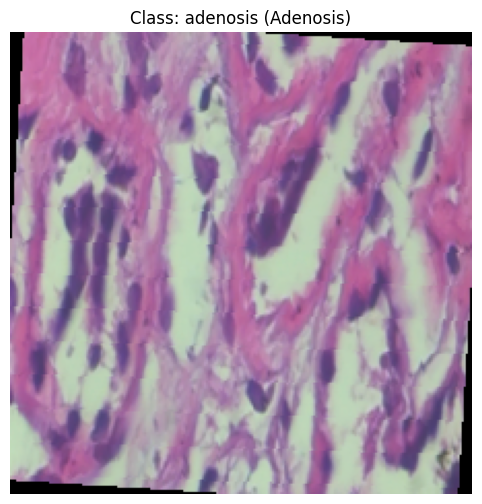

Image path: D:\thesis work\densnet-thesis\datatfull\BreaKHis_v1\histology_slides\breast\benign\SOB\adenosis\SOB_B_A_14-22549G\400X\SOB_B_A-14-22549G-400-001.png
Magnification: 400X
Label: 0 (adenosis)


In [6]:
# ============================================================================
# CELL 5: DATA PREPROCESSING AND AUGMENTATION
# ============================================================================

def get_transforms():
    """Get train and test transforms for histopathology images"""
    
    # Training transforms with augmentation
    train_transform = transforms.Compose([
        transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(degrees=15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])
    ])
    
    # Test/validation transforms (no augmentation)
    test_transform = transforms.Compose([
        transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])
    ])
    
    return train_transform, test_transform

# Test the dataset class with FIXED version
print("Testing FIXED dataset class (400X only)...")
print("="*60)

# Create sample datasets - ONLY 400X
train_transform, test_transform = get_transforms()

# Create datasets with correct path
train_dataset = BreakHisDataset(
    base_path=r"D:\thesis work\densnet-thesis\datatfull\BreaKHis_v1",  # Use raw string
    transform=train_transform,
    magnification='400X',  # Only 400X
    mode='train'
)

val_dataset = BreakHisDataset(
    base_path=r"D:\thesis work\densnet-thesis\datatfull\BreaKHis_v1",
    transform=test_transform,
    magnification='400X',
    mode='val'
)

test_dataset = BreakHisDataset(
    base_path=r"D:\thesis work\densnet-thesis\datatfull\BreaKHis_v1",
    transform=test_transform,
    magnification='400X',
    mode='test'
)

print(f"\n" + "="*60)
print(f"Dataset sizes (400X only):")
print(f"Training: {len(train_dataset)} images")
print(f"Validation: {len(val_dataset)} images")
print(f"Test: {len(test_dataset)} images")

if len(train_dataset) > 0:
    print(f"\nTraining class distribution:")
    train_dist = train_dataset.get_class_distribution()
    
    # Format nicely
    print(f"{'Class':<25} {'Count':>6}")
    print("-" * 35)
    for cls, count in train_dist.items():
        print(f"{cls:<25} {count:>6}")
    
    print(f"\nTraining magnification distribution:")
    print(train_dataset.get_magnification_distribution())
    
    # Show a sample
    print(f"\nShowing first sample from training set:")
    train_dataset.show_sample(0)
else:
    print("\nERROR: No images loaded! Check the base_path.")
    
    # Debug: Show what's in the base directory
    base_path = r"D:\thesis work\densnet-thesis\datatfull\BreaKHis_v1"
    if os.path.exists(base_path):
        print(f"\nContents of {base_path}:")
        for item in os.listdir(base_path):
            item_path = os.path.join(base_path, item)
            if os.path.isdir(item_path):
                print(f"  📁 {item}/")
            else:
                print(f"  📄 {item}")
    else:
        print(f"\nERROR: Base path does not exist: {base_path}")

# DATA LOADERS

In [7]:
def create_data_loaders_safe(batch_size=config.BATCH_SIZE):
    """Create data loaders with proper error handling"""
    
    # First verify the path
    print("Checking dataset path...")
    if not os.path.exists(config.DATA_DIR):
        print(f"ERROR: config.DATA_DIR does not exist: {config.DATA_DIR}")
        print(f"Current config.DATA_DIR value: {repr(config.DATA_DIR)}")
        
        # Try common variations
        test_paths = [
            r"D:\thesis work\densnet-thesis\datatfull\BreaKHis_v1",
            "D:/thesis work/densnet-thesis/datatfull/BreaKHis_v1",
            "D:\\thesis work\\densnet-thesis\\datatfull\\BreaKHis_v1",
        ]
        
        for test_path in test_paths:
            if os.path.exists(test_path):
                print(f"Found dataset at: {test_path}")
                config.DATA_DIR = test_path
                break
        else:
            print("ERROR: Could not find dataset in any expected location!")
            return None, None, None
    
    print(f"Using dataset path: {config.DATA_DIR}")
    
    train_transform, test_transform = get_transforms()
    
    # Create datasets with explicit path
    print("\nCreating training dataset...")
    train_dataset = BreakHisDataset(
        base_path=config.DATA_DIR,  # Explicit path
        transform=train_transform,
        magnification='400X',  # Changed from 'all' to '400X'
        mode='train'
    )
    
    if len(train_dataset) == 0:
        print("ERROR: Training dataset is empty!")
        print("\nDebug: Let's check the folder structure manually...")
        check_folder_structure(config.DATA_DIR)
        return None, None, None
    
    print("Creating validation dataset...")
    val_dataset = BreakHisDataset(
        base_path=config.DATA_DIR,
        transform=test_transform,
        magnification='400X',
        mode='val'
    )
    
    print("Creating test dataset...")
    test_dataset = BreakHisDataset(
        base_path=config.DATA_DIR,
        transform=test_transform,
        magnification='400X',
        mode='test'
    )
    
    # Check dataset sizes
    print(f"\nDataset sizes:")
    print(f"Training: {len(train_dataset)} images")
    print(f"Validation: {len(val_dataset)} images")
    print(f"Test: {len(test_dataset)} images")
    
    if len(train_dataset) == 0 or len(val_dataset) == 0 or len(test_dataset) == 0:
        print("ERROR: One or more datasets are empty!")
        return None, None, None
    
    # Create data loaders
    try:
        train_loader = DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True,
            num_workers=0,  # Start with 0 for debugging
            pin_memory=True
        )
        
        val_loader = DataLoader(
            val_dataset,
            batch_size=batch_size,
            shuffle=False,
            num_workers=0,
            pin_memory=True
        )
        
        test_loader = DataLoader(
            test_dataset,
            batch_size=batch_size,
            shuffle=False,
            num_workers=0,
            pin_memory=True
        )
        
        print("\n✅ Data loaders created successfully!")
        print(f"Train batches: {len(train_loader)}")
        print(f"Val batches: {len(val_loader)}")
        print(f"Test batches: {len(test_loader)}")
        
        # Show sample batch
        try:
            sample_batch, sample_labels = next(iter(train_loader))
            print(f"\nSample batch shape: {sample_batch.shape}")
            print(f"Sample labels shape: {sample_labels.shape}")
            print(f"Unique labels in batch: {torch.unique(sample_labels).tolist()}")
        except:
            print("Could not load sample batch")
        
        return train_loader, val_loader, test_loader
        
    except Exception as e:
        print(f"ERROR creating data loaders: {e}")
        return None, None, None

def check_folder_structure(base_path):
    """Manually check the folder structure"""
    print(f"\nChecking structure of: {base_path}")
    
    if not os.path.exists(base_path):
        print("Base path does not exist!")
        return
    
    # Check for histology_slides
    histology_path = os.path.join(base_path, "histology_slides")
    if os.path.exists(histology_path):
        print(f"✓ Found: histology_slides/")
        
        # Check for breast folder
        breast_path = os.path.join(histology_path, "breast")
        if os.path.exists(breast_path):
            print(f"  ✓ Found: breast/")
            
            # Check for benign/malignant
            for malignancy in ["benign", "malignant"]:
                mal_path = os.path.join(breast_path, malignancy)
                if os.path.exists(mal_path):
                    print(f"    ✓ Found: {malignancy}/")
                    
                    # Check for SOB
                    sob_path = os.path.join(mal_path, "SOB")
                    if os.path.exists(sob_path):
                        print(f"      ✓ Found: SOB/")
                        
                        # List class folders
                        class_folders = os.listdir(sob_path)[:3]  # Show first 3
                        for cls in class_folders:
                            cls_path = os.path.join(sob_path, cls)
                            if os.path.isdir(cls_path):
                                print(f"        ✓ Found: {cls}/")
                else:
                    print(f"    ✗ Missing: {malignancy}/")
        else:
            print(f"  ✗ Missing: breast/")
    else:
        print(f"✗ Missing: histology_slides/")
        print("\nTop-level contents:")
        for item in os.listdir(base_path):
            item_path = os.path.join(base_path, item)
            if os.path.isdir(item_path):
                print(f"  📁 {item}/")
            else:
                print(f"  📄 {item}")

# Pre Process Data


In [30]:
#Config 
# Example usage
PREPROCESSING_CONFIG = {
    "stain_normalization": True,
    "image_enhancement": True,
    "geometric_augmentation": True,
    "color_augmentation": True,
    "advanced_augmentation": True,
    "class_balancing": True
}


# Preprocessing — Stain Normalization

Core stain normalization utilities (Macenko & Reinhard). Run this cell after `PREPROCESSING_CONFIG` is defined.


In [10]:
# PREPROCESSING CELL 1: Stain Normalization (inserted from all_preprocessing_cells.py)
import cv2
import numpy as np
from scipy.linalg import lstsq

class StainNormalizer:
    def __init__(self, method='macenko'):
        self.method = method
        
    def macenko_normalize(self, image):
        "Macenko stain normalization"
        od = -np.log((image.astype(np.float64) + 1) / 256.0)
        od_hat = od[~np.any(od < 0.15, axis=2)]
        eigvals, eigvecs = np.linalg.eigh(np.cov(od_hat.T))
        eigvecs = eigvecs[:, np.argsort(eigvals)[::-1]]
        that = od_hat.dot(eigvecs[:, :2])
        phi = np.arctan2(that[:, 1], that[:, 0])
        min_phi, max_phi = np.percentile(phi, [1, 99])
        v1 = eigvecs[:, :2].dot([np.cos(min_phi), np.sin(min_phi)])
        v2 = eigvecs[:, :2].dot([np.cos(max_phi), np.sin(max_phi)])
        he = np.array([v1, v2]) if v1[0] > v2[0] else np.array([v2, v1])
        he = he / np.linalg.norm(he, axis=1, keepdims=True)
        target_he = np.array([[0.65, 0.70, 0.29], [0.07, 0.99, 0.11]])
        c = lstsq(he.T, od.reshape(-1, 3).T)[0]
        max_c = np.percentile(c, 99, axis=1, keepdims=True)
        c = c / max_c * np.percentile(target_he, 99, axis=1, keepdims=True).T
        normalized = np.exp(-target_he.T.dot(c)) * 255
        return np.clip(normalized.T.reshape(image.shape), 0, 255).astype(np.uint8)
    
    def reinhard_normalize(self, image):
        "Reinhard color normalization in LAB space"
        lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB).astype(np.float64)
        target_means = np.array([8.63234435, -0.11501964, 0.03868433])
        target_stds = np.array([0.57506023, 0.10403329, 0.01364062])
        means = np.mean(lab.reshape(-1, 3), axis=0)
        stds = np.std(lab.reshape(-1, 3), axis=0)
        lab = (lab - means) / stds * target_stds + target_means
        return cv2.cvtColor(lab.astype(np.uint8), cv2.COLOR_LAB2RGB)
    
    def normalize(self, image):
        if self.method == 'macenko':
            return self.macenko_normalize(image)
        elif self.method == 'reinhard':
            return self.reinhard_normalize(image)
        return image

stain_normalizer = StainNormalizer(method=PREPROCESSING_CONFIG.get('stain_method', 'macenko'))
print(f"Stain normalizer initialized: {PREPROCESSING_CONFIG.get('stain_method', 'macenko')}")


Stain normalizer initialized: macenko


# Preprocessing — Color Augmentation

Color jitter and HSV-based augmentations tailored for H&E stained images.


In [11]:
# PREPROCESSING CELL 2: Color Augmentation
import torchvision.transforms as transforms
import torch
import random

class ColorAugmentation:
    def __init__(self, hue_range=0.15, saturation_range=0.2, brightness_range=0.2, contrast_range=0.2):
        self.color_jitter = transforms.ColorJitter(
            brightness=brightness_range,
            contrast=contrast_range,
            saturation=saturation_range,
            hue=hue_range
        )
        
    def __call__(self, image):
        if random.random() > 0.5:
            return self.color_jitter(image)
        return image

class HSVAugmentation:
    def __init__(self, hue_shift=15, sat_shift=20, val_shift=20):
        self.hue_shift = hue_shift
        self.sat_shift = sat_shift
        self.val_shift = val_shift
        
    def __call__(self, image):
        if isinstance(image, torch.Tensor):
            image = transforms.ToPILImage()(image)
        hsv = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2HSV).astype(np.float32)
        hsv[:,:,0] += random.uniform(-self.hue_shift, self.hue_shift)
        hsv[:,:,1] *= random.uniform(1-self.sat_shift/100, 1+self.sat_shift/100)
        hsv[:,:,2] *= random.uniform(1-self.val_shift/100, 1+self.val_shift/100)
        hsv[:,:,0] = np.clip(hsv[:,:,0], 0, 179)
        hsv[:,:,1] = np.clip(hsv[:,:,1], 0, 255)
        hsv[:,:,2] = np.clip(hsv[:,:,2], 0, 255)
        rgb = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)
        return transforms.ToTensor()(rgb)

color_aug = ColorAugmentation()
hsv_aug = HSVAugmentation()
print("Color augmentation transforms initialized")


Color augmentation transforms initialized


# Preprocessing — Geometric Augmentations

Rotation, flips, elastic transforms and histology-specific geometric augmentations.


In [12]:
import torchvision.transforms as transforms
import torchvision.transforms.functional as F
import torch
import random

class HistologyAugmentation:
    def __init__(self, img_size=224):
        self.img_size = img_size
        self.transforms = transforms.Compose([
            # Use custom rotation restricted to multiples of 90°
            Random90Rotation(),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
            transforms.RandomResizedCrop(img_size, scale=(0.8, 1.0)),
            transforms.RandomAffine(degrees=5, translate=(0.1, 0.1), scale=(0.9, 1.1))
        ])
    def __call__(self, image):
        return self.transforms(image)

class Random90Rotation:
    def __call__(self, img):
        angles = [0, 90, 180, 270]
        angle = random.choice(angles)
        return F.rotate(img, angle)


# Preprocessing — Advanced Augmentations

MixUp, CutMix and Random Erasing implementations for stronger regularization.


In [13]:
# PREPROCESSING CELL 4: Advanced Augmentations (MixUp, CutMix, Random Erasing)
import torch
import numpy as np
import random

class MixUp:
    def __init__(self, alpha=0.2):
        self.alpha = alpha
    def __call__(self, batch_x, batch_y):
        if self.alpha > 0:
            lam = np.random.beta(self.alpha, self.alpha)
        else:
            lam = 1
        batch_size = batch_x.size(0)
        index = torch.randperm(batch_size)
        mixed_x = lam * batch_x + (1 - lam) * batch_x[index, :]
        y_a, y_b = batch_y, batch_y[index]
        return mixed_x, y_a, y_b, lam

class CutMix:
    def __init__(self, alpha=1.0):
        self.alpha = alpha
    def __call__(self, batch_x, batch_y):
        lam = np.random.beta(self.alpha, self.alpha)
        batch_size = batch_x.size(0)
        index = torch.randperm(batch_size)
        y_a, y_b = batch_y, batch_y[index]
        bbx1, bby1, bbx2, bby2 = self.rand_bbox(batch_x.size(), lam)
        batch_x[:, :, bbx1:bbx2, bby1:bby2] = batch_x[index, :, bbx1:bbx2, bby1:bby2]
        lam = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (batch_x.size()[-1] * batch_x.size()[-2]))
        return batch_x, y_a, y_b, lam
    def rand_bbox(self, size, lam):
        W = size[2]
        H = size[3]
        cut_rat = np.sqrt(1. - lam)
        cut_w = np.int(W * cut_rat)
        cut_h = np.int(H * cut_rat)
        cx = np.random.randint(W)
        cy = np.random.randint(H)
        bbx1 = np.clip(cx - cut_w // 2, 0, W)
        bby1 = np.clip(cy - cut_h // 2, 0, H)
        bbx2 = np.clip(cx + cut_w // 2, 0, W)
        bby2 = np.clip(cy + cut_h // 2, 0, H)
        return bbx1, bby1, bbx2, bby2

class RandomErasing:
    def __init__(self, probability=0.15, sl=0.02, sh=0.15, r1=0.3):
        self.probability = probability
        self.sl = sl
        self.sh = sh
        self.r1 = r1
    def __call__(self, img):
        if random.uniform(0, 1) > self.probability:
            return img
        for attempt in range(100):
            area = img.size()[1] * img.size()[2]
            target_area = random.uniform(self.sl, self.sh) * area
            aspect_ratio = random.uniform(self.r1, 1/self.r1)
            h = int(round(np.sqrt(target_area * aspect_ratio)))
            w = int(round(np.sqrt(target_area / aspect_ratio)))
            if w < img.size()[2] and h < img.size()[1]:
                x1 = random.randint(0, img.size()[1] - h)
                y1 = random.randint(0, img.size()[2] - w)
                img[0, x1:x1+h, y1:y1+w] = random.random()
                img[1, x1:x1+h, y1:y1+w] = random.random()
                img[2, x1:x1+h, y1:y1+w] = random.random()
                return img
        return img

mixup = MixUp(alpha=0.2)
cutmix = CutMix(alpha=1.0)
random_erasing = RandomErasing(probability=0.15)
print("Advanced augmentation methods initialized")


Advanced augmentation methods initialized


# Preprocessing — Patch Extraction Strategy

Extract overlapping tissue patches and build a multipatch dataset for training/fine-tuning.


In [14]:
# PREPROCESSING CELL 5: Patch Extraction Strategy
import torch
from torch.utils.data import Dataset
import cv2
from PIL import Image

class PatchExtractor:
    def __init__(self, patch_size=224, overlap=0.5, min_tissue_ratio=0.7):
        self.patch_size = patch_size
        self.overlap = overlap
        self.min_tissue_ratio = min_tissue_ratio
        self.stride = int(patch_size * (1 - overlap))
    def extract_patches(self, image):
        if isinstance(image, torch.Tensor):
            image = image.permute(1, 2, 0).numpy()
        elif isinstance(image, Image.Image):
            image = np.array(image)
        h, w = image.shape[:2]
        patches = []
        positions = []
        for y in range(0, h - self.patch_size + 1, self.stride):
            for x in range(0, w - self.patch_size + 1, self.stride):
                patch = image[y:y+self.patch_size, x:x+self.patch_size]
                if self._has_sufficient_tissue(patch):
                    patches.append(patch)
                    positions.append((x, y))
        return patches, positions
    def _has_sufficient_tissue(self, patch):
        if len(patch.shape) == 3:
            gray = cv2.cvtColor(patch, cv2.COLOR_RGB2GRAY)
        else:
            gray = patch
        tissue_mask = gray < 230
        tissue_ratio = np.sum(tissue_mask) / (patch.shape[0] * patch.shape[1])
        return tissue_ratio >= self.min_tissue_ratio

class MultiPatchDataset(Dataset):
    def __init__(self, images, labels, patch_extractor, transform=None):
        self.patch_extractor = patch_extractor
        self.transform = transform
        self.patches = []
        self.labels = []
        for img, label in zip(images, labels):
            patches, _ = self.patch_extractor.extract_patches(img)
            for patch in patches:
                self.patches.append(patch)
                self.labels.append(label)
    def __len__(self):
        return len(self.patches)
    def __getitem__(self, idx):
        patch = self.patches[idx]
        label = self.labels[idx]
        if self.transform:
            patch = self.transform(patch)
        return patch, label

patch_extractor = PatchExtractor(patch_size=224, overlap=0.5)
print("Patch extraction strategy initialized")


Patch extraction strategy initialized


# Preprocessing — Class Imbalance Handling

Focal loss and sample weighting (WeightedRandomSampler) utilities to mitigate class imbalance.


In [15]:
# PREPROCESSING CELL 6: Class Imbalance Handling
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import WeightedRandomSampler
from collections import Counter
import numpy as np

class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, num_classes=8, size_average=True):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.num_classes = num_classes
        self.size_average = size_average
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1-pt)**self.gamma * ce_loss
        if self.size_average:
            return focal_loss.mean()
        else:
            return focal_loss.sum()

class ClassBalancer:
    def __init__(self, labels):
        self.labels = labels
        self.class_counts = Counter(labels)
        self.num_classes = len(self.class_counts)
    def get_class_weights(self):
        total_samples = len(self.labels)
        weights = []
        for i in range(self.num_classes):
            weight = total_samples / (self.num_classes * self.class_counts.get(i, 1))
            weights.append(weight)
        return torch.FloatTensor(weights)
    def get_sample_weights(self):
        class_weights = self.get_class_weights()
        sample_weights = [class_weights[label] for label in self.labels]
        return torch.FloatTensor(sample_weights)
    def create_balanced_sampler(self):
        sample_weights = self.get_sample_weights()
        return WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

class_names = ['Adenosis', 'Fibroadenoma', 'Phyllodes_tumor', 'Tubular_adenoma', 'Ductal_carcinoma', 'Lobular_carcinoma', 'Mucinous_carcinoma', 'Papillary_carcinoma']
focal_loss = FocalLoss(alpha=1, gamma=2, num_classes=len(class_names))
print("Class imbalance handling initialized with Focal Loss")


Class imbalance handling initialized with Focal Loss


# Preprocessing — Image Quality Enhancement

CLAHE contrast enhancement, background removal and related helpers.


In [ ]:
# PREPROCESSING CELL 7: Image Quality Enhancement
import cv2
import numpy as np
from skimage import morphology
from scipy import ndimage

class ImageEnhancer:
    def __init__(self, clahe_clip_limit=2.0, clahe_tile_size=(8,8)):
        self.clahe = cv2.createCLAHE(clipLimit=clahe_clip_limit, tileGridSize=clahe_tile_size)
    def apply_clahe(self, image):
        if len(image.shape) == 3:
            lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
            lab[:,:,0] = self.clahe.apply(lab[:,:,0])
            enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
        else:
            enhanced = self.clahe.apply(image)
        return enhanced
    def remove_background(self, image, threshold=230):
        if len(image.shape) == 3:
            gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        else:
            gray = image.copy()
        tissue_mask = gray < threshold
        tissue_mask = morphology.remove_small_objects(tissue_mask, min_size=1000)
        tissue_mask = morphology.remove_small_holes(tissue_mask, area_threshold=1000)
        kernel = np.ones((5,5), np.uint8)
        tissue_mask = cv2.morphologyEx(tissue_mask.astype(np.uint8), cv2.MORPH_CLOSE, kernel)
        tissue_mask = cv2.morphologyEx(tissue_mask, cv2.MORPH_OPEN, kernel)
        # ensure mask is boolean before using ~ for indexing
        tissue_mask = tissue_mask.astype(bool)
        if len(image.shape) == 3:
            result = image.copy()
            result[~tissue_mask] = [255, 255, 255]
        else:
            result = image.copy()
            result[~tissue_mask] = 255
        return result, tissue_mask
    def enhance_image(self, image):
        enhanced, mask = self.remove_background(image)
        enhanced = self.apply_clahe(enhanced)
        enhanced = cv2.GaussianBlur(enhanced, (3, 3), 0)
        return enhanced

class BackgroundRemover:
    def __init__(self, threshold=0.8):
        self.threshold = threshold
    def remove_white_background(self, image):
        if isinstance(image, torch.Tensor):
            image = image.permute(1, 2, 0).numpy()
        hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
        lower_white = np.array([0, 0, 200])
        upper_white = np.array([180, 30, 255])
        white_mask = cv2.inRange(hsv, lower_white, upper_white)
        tissue_mask = cv2.bitwise_not(white_mask)
        result = image.copy()
        result[white_mask > 0] = [255, 255, 255]
        return result

image_enhancer = ImageEnhancer()
background_remover = BackgroundRemover()
print("Image quality enhancement tools initialized")


Image quality enhancement tools initialized


# Preprocessing — Complete Pipeline Integration

Wraps stain normalization, enhancement and augmentations into a reusable pipeline and DataLoader helper.


In [18]:
# PREPROCESSING CELL: Complete Preprocessing Pipeline Integration
import torchvision.transforms as transforms
import torchvision.transforms.functional as F
from torch.utils.data import DataLoader
import random

# Custom transform for rotations restricted to multiples of 90°
class Random90Rotation:
    def __call__(self, img):
        angle = random.choice([0, 90, 180, 270])
        return F.rotate(img, angle)

class BreakHisPreprocessingPipeline:
    def __init__(self, config, img_size=224):
        self.config = config
        self.img_size = img_size
        if config.get('stain_normalization', False):
            self.stain_normalizer = StainNormalizer(method=config.get('stain_method', 'macenko'))
        if config.get('image_enhancement', False):
            self.image_enhancer = ImageEnhancer()
        self.train_transforms = self._build_train_transforms()
        self.val_transforms = self._build_val_transforms()

    def _build_train_transforms(self):
        transforms_list = []
        transforms_list.extend([
            transforms.ToPILImage(),
            transforms.Resize((self.img_size, self.img_size))
        ])
        if self.config.get('geometric_augmentation', False):
            transforms_list.extend([
                Random90Rotation(),  # fixed rotation
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomVerticalFlip(p=0.5),
                transforms.RandomResizedCrop(self.img_size, scale=(0.8, 1.0))
            ])
        if self.config.get('color_augmentation', False):
            transforms_list.append(
                transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.15)
            )
        transforms_list.extend([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])
        if self.config.get('advanced_augmentation', False):
            transforms_list.append(RandomErasing(probability=0.15))
        return transforms.Compose(transforms_list)

    def _build_val_transforms(self):
        return transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((self.img_size, self.img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

    def preprocess_image(self, image, is_training=True):
        if self.config.get('image_enhancement', False):
            image = self.image_enhancer.enhance_image(image)
        if self.config.get('stain_normalization', False):
            image = self.stain_normalizer.normalize(image)
        if is_training:
            return self.train_transforms(image)
        else:
            return self.val_transforms(image)

    def create_data_loader(self, dataset, batch_size=32,
                           is_training=True, class_balancing=True):
        if is_training and class_balancing and self.config.get('class_balancing', False):
            labels = [dataset[i][1] for i in range(len(dataset))]
            balancer = ClassBalancer(labels)
            sampler = balancer.create_balanced_sampler()
            return DataLoader(dataset, batch_size=batch_size,
                              sampler=sampler, num_workers=4, pin_memory=True)
        else:
            return DataLoader(dataset, batch_size=batch_size,
                              shuffle=is_training, num_workers=4, pin_memory=True)

# Example usage
PREPROCESSING_CONFIG = {
    "stain_normalization": True,
    "image_enhancement": True,
    "geometric_augmentation": True,
    "color_augmentation": True,
    "advanced_augmentation": True,
    "class_balancing": True
}

preprocessing_pipeline = BreakHisPreprocessingPipeline(config=PREPROCESSING_CONFIG)
print("Complete preprocessing pipeline initialized")
print(f"Configuration: {PREPROCESSING_CONFIG}")


Complete preprocessing pipeline initialized
Configuration: {'stain_normalization': True, 'image_enhancement': True, 'geometric_augmentation': True, 'color_augmentation': True, 'advanced_augmentation': True, 'class_balancing': True}


In [19]:
### Visualizing Preprocessing Steps
Below is an example that takes a raw image (either loaded manually or pulled from an
existing dataset) and runs it through the pipeline.  The cell shows the original
image plus the output of the **training** and **validation** transform sequences.


SyntaxError: invalid syntax (1025558116.py, line 2)

IndexError: index 254 is out of bounds for axis 0 with size 224

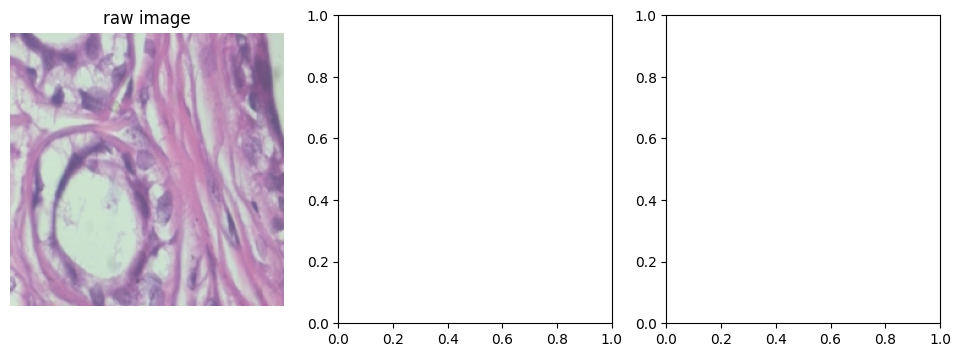

In [22]:
# example showing a pipeline input & output
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch

# helper to un-normalize and display a tensor

def imshow_tensor(tensor, title=None):
    tensor = tensor.clone().detach().cpu()
    mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
    std  = torch.tensor([0.229,0.224,0.225]).view(3,1,1)
    img = tensor * std + mean             # reverse normalization
    img = img.permute(1,2,0).numpy()
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    if title:
        plt.title(title)
    plt.axis('off')

# load a sample image (replace with a valid path or dataset lookup)
# sample_path = r"D:\thesis work\densnet-thesis\datasets\BreaKHis 400X\some_image.png"
# raw = np.array(Image.open(sample_path).convert('RGB'))

# alternatively, grab the first image from an existing dataset if available
raw = None
if 'test_dataset' in globals():
    try:
        raw, _ = test_dataset[0]
        # test_dataset may already return transformed tensors; convert back
        if isinstance(raw, torch.Tensor):
            raw = raw.permute(1,2,0).numpy()
            raw = (raw * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406]))
            raw = (raw * 255).astype(np.uint8)
    except Exception:
        raw = None

if raw is None:
    raise RuntimeError("No sample image available; set `sample_path` or provide `test_dataset`.")

fig, axes = plt.subplots(1,3, figsize=(12,4))
axes[0].imshow(raw)
axes[0].set_title('raw image'); axes[0].axis('off')

train_tensor = preprocessing_pipeline.preprocess_image(raw, is_training=True)
val_tensor   = preprocessing_pipeline.preprocess_image(raw, is_training=False)

axes[1].imshow(imshow_tensor(train_tensor))
axes[1].set_title('train transforms'); axes[1].axis('off')

axes[2].imshow(imshow_tensor(val_tensor))
axes[2].set_title('val transforms'); axes[2].axis('off')

plt.show()


# Model

In [23]:
# Setup imports and paths
import os
import sys
from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt

# Make sure repository root is on sys.path (adjust if you open the notebook from a different folder)
REPO_ROOT = Path('..').resolve() if Path('.').name == 'notebooks' else Path('.').resolve()
print(f'REPO_ROOT = {REPO_ROOT}')
sys.path.insert(0, str(REPO_ROOT))

# Helpful device selection
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)

REPO_ROOT = D:\thesis work\densnet-thesis\notebooks
Using device: cpu


In [24]:
from pathlib import Path  # <-- add this at the top
import os
from datetime import datetime

# User-editable settings
# Allow override from environment variable MODEL_PATH (convenient for CI / shells)
MODEL_PATH = os.environ.get('MODEL_PATH', None)
DATA_ROOT = None
NUM_BENCH_SAMPLES = 10
NUM_EXPLAIN_SAMPLES = 3

# If you know the folder containing your checkpoint, set it here (the notebook will pick the newest file inside).
# Example (you provided this path):
DEFAULT_MODEL_DIR = Path(r'D:\thesis work\densnet-thesis\weight\save\40')

# Auto-discover model if MODEL_PATH is None
if MODEL_PATH is None:
    # Common places to look for checkpoints (DEFAULT_MODEL_DIR is included first)
    search_roots = [DEFAULT_MODEL_DIR, Path('weight'), Path('weight/save'), Path('models'), Path('model'), Path('checkpoints'), Path('.')]
    patterns = ['*.pth', '*.pt', '*.pth.tar', '*.tar']
    candidates = []
    for root in search_roots:
        try:
            if root.exists():
                for pat in patterns:
                    candidates.extend(list(root.rglob(pat)))
        except Exception:
            # ignore permissions/IO errors for some roots
            continue

    # deduplicate and sort by modification time (newest first)
    unique = {str(p): p for p in candidates}
    candidates = list(unique.values())
    candidates = sorted(candidates, key=lambda p: p.stat().st_mtime if p.exists() else 0, reverse=True)
    candidates = [str(p) for p in candidates]
    if candidates:
        print('Found candidate checkpoints (sorted by modification time, newest first):')
        for c in candidates[:10]:
            try:
                mtime = datetime.fromtimestamp(Path(c).stat().st_mtime).isoformat()
            except Exception:
                mtime = 'unknown'
            print(' -', c, '(mtime:', mtime + ')')
        MODEL_PATH = candidates[0]
    else:
        print('No checkpoint auto-discovered. Please set MODEL_PATH to your checkpoint file path or set the MODEL_PATH environment variable.')
else:
    # If user set MODEL_PATH to a directory, pick the newest checkpoint inside it
    mp = Path(MODEL_PATH)
    if mp.exists() and mp.is_dir():
        patterns = ['*.pth', '*.pt', '*.pth.tar', '*.tar']
        cand = []
        for pat in patterns:
            cand.extend(list(mp.rglob(pat)))
        cand = sorted({str(p): p for p in cand}.values(), key=lambda p: p.stat().st_mtime if p.exists() else 0, reverse=True)
        if cand:
            MODEL_PATH = str(cand[0])
            print(f'MODEL_PATH was a directory; selecting newest checkpoint inside: {MODEL_PATH}')
        else:
            print(f'MODEL_PATH points to a directory but no checkpoints were found inside: {MODEL_PATH}')
    else:
        print('MODEL_PATH provided via environment variable or earlier assignment.')

print('MODEL_PATH =', MODEL_PATH)


Found candidate checkpoints (sorted by modification time, newest first):
 - D:\thesis work\densnet-thesis\weight\save\40\iaff40_5.pth (mtime: 2025-10-13T03:03:24.372919)
MODEL_PATH = D:\thesis work\densnet-thesis\weight\save\40\iaff40_5.pth


# model evaludate

In [25]:
# Robust model loader: handles checkpoints that store 'model' or 'model_state_dict'
import torch
import sys
from importlib import import_module
import numpy as np
# Ensure repository root is on sys.path so local modules (config, model.*) can be imported
sys.path.insert(0, r'D:\thesis work\densnet-thesis')
import config

def load_checkpoint_model(checkpoint_path, device=DEVICE):
    # Use safe_globals to allowlist numpy types needed by this checkpoint (trusted local file)
    with torch.serialization.safe_globals([np._core.multiarray.scalar, np.dtype]):
        checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model = None
    # If the checkpoint saved the whole model object (common in this repo)
    if isinstance(checkpoint, dict) and 'model' in checkpoint:
        model = checkpoint['model']
        model.to(device)
        model.eval()
        print('Loaded model object from checkpoint.')
        return model, device

    # If a state_dict is present, attempt to instantiate a model and load the weights
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        print('Checkpoint contains state_dict. Attempting to instantiate model and load weights...')
        # Try common model factories found in repository
        try:
            # Try multiclass factory first
            from model.multiclass_model import create_multiclass_model
            model = create_multiclass_model(num_classes=getattr(config, 'class_num', 2))
            model.load_state_dict(checkpoint['model_state_dict'])
            model.to(device)
            model.eval()
            print('Instantiated MultiClass model and loaded state_dict.')
            return model, device
        except Exception as e_mult:
            print('Multiclass factory failed:', e_mult)
        try:
            from model.model import class_model
            model = class_model()
            model.load_state_dict(checkpoint['model_state_dict'])
            model.to(device)
            model.eval()
            print('Instantiated binary/class_model and loaded state_dict.')
            return model, device
        except Exception as e_bin:
            print('Binary factory failed:', e_bin)

    # If checkpoint is just a model object (not dict) try that
    if not isinstance(checkpoint, dict):
        try:
            model = checkpoint
            model.to(device)
            model.eval()
            print('Checkpoint appears to be a model object (direct load).')
            return model, device
        except Exception as e_obj:
            print('Could not use checkpoint as model object:', e_obj)

    raise RuntimeError('Failed to load model from checkpoint. Please inspect the checkpoint file or update the loader cell.')

# Try to load if MODEL_PATH was discovered
model = None
if MODEL_PATH:
    model, DEVICE = load_checkpoint_model(MODEL_PATH, DEVICE)
else:
    print('No MODEL_PATH set. Set MODEL_PATH and re-run this cell to load the model.')


Loaded model object from checkpoint.


In [26]:
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from pathlib import Path

IMG_SIZE = 224
MEAN = (0.485, 0.456, 0.406)
STD = (0.229, 0.224, 0.225)
BATCH_SIZE = 32
NUM_WORKERS = 0

# Root folder containing subfolders for each class (benign, malignant, etc.)
data_root = r"D:\thesis work\densnet-thesis\datasets\BreaKHis 400X\test"
print('Using data root for test set:', data_root)

# Check path exists
if not Path(data_root).exists():
    raise FileNotFoundError(f"Dataset path does not exist: {data_root}")

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

# ImageFolder expects: test/class_name/*.png
test_dataset = ImageFolder(data_root, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f'Test dataset size: {len(test_dataset)} samples, batches: {len(test_loader)}')
class_names = test_dataset.classes
print('Class names:', class_names)


Using data root for test set: D:\thesis work\densnet-thesis\datasets\BreaKHis 400X\test
Test dataset size: 545 samples, batches: 18
Class names: ['benign', 'malignant']


# evluator

In [27]:
# Run evaluation (accuracy, precision, recall, f1, confusion matrix, ROC-AUC for binary)
from evaluation.metrics import ModelEvaluator
import numpy as np
import json

evaluator = ModelEvaluator(class_names=class_names)
results = evaluator.evaluate_model(
    model, test_loader, device=DEVICE,
    save_results=True, save_dir='notebook_evaluation_results'
)

# Print a compact summary
metrics = results['metrics']
print('Overall metrics:')
for k in ['accuracy', 'precision', 'recall', 'f1_score']:
    print(f' - {k}:', metrics.get(k))

if 'confusion_matrix' in metrics:
    print('\nConfusion matrix:')
    print(np.array(metrics['confusion_matrix']))

# Save summary JSON for convenience
with open('notebook_evaluation_results/summary.json', 'w') as f:
    json.dump(results, f, indent=2)
print('Saved evaluation summary to notebook_evaluation_results/summary.json')


ModuleNotFoundError: No module named 'plotly'

In [28]:
# Generate explanations for a few sample images and visualize (Grad-CAM, Grad-CAM++, SHAP, LIME where available)
import torch.nn.functional as F
from explainability.grad_cam import GradCAM, GradCAMPlusPlus, overlay_heatmap
from explainability.shap_explainer import SHAPExplainer
from explainability.lime_explainer import LIMEExplainer

# Helper: convert tensor -> displayable image (denormalize)
def tensor_to_image(tensor, mean=MEAN, std=STD):
    denorm = tensor.clone()
    for c in range(3):
        denorm[0, c] = denorm[0, c] * std[c] + mean[c]
    img = denorm[0].cpu().numpy().transpose(1,2,0)
    img = np.clip(img, 0, 1)
    return img

# Sample few images from test_loader
samples = []
for images, labels in test_loader:
    for i in range(min(images.size(0), NUM_EXPLAIN_SAMPLES - len(samples))):
        samples.append((images[i:i+1].to(DEVICE), int(labels[i].item())))
    if len(samples) >= NUM_EXPLAIN_SAMPLES:
        break

# Initialize simple explainers for single-sample visualization
# Choose a target layer name heuristically
layer_name_candidates = ['densenet.features.norm5','features.norm5','norm5']
# pick first available target layer from model modules
layer_names = [name for name, _ in model.named_modules()]
target_layer = next((ln for ln in layer_name_candidates if ln in layer_names), None)
if target_layer is None:
    convs = [n for n in layer_names if 'conv' in n.lower()]
    target_layer = convs[-1] if convs else None
print('Using Grad-CAM target layer:', target_layer)

try:
    gradcam = GradCAM(model, target_layer_name=target_layer) if target_layer else None
    gradcam_plus = GradCAMPlusPlus(model, target_layer_name=target_layer) if target_layer else None
    print('Grad-CAM instances ready')
except Exception as e:
    print('Grad-CAM init failed:', e)
    gradcam = gradcam_plus = None

# Optionally initialize SHAP and LIME (may be slow)
shap_explainer = None
lime_explainer = None
try:
    shap_explainer = SHAPExplainer(model, torch.randn(3,3,IMG_SIZE,IMG_SIZE).to(DEVICE), str(DEVICE))
    print('SHAP explainer ready')
except Exception as e:
    print('SHAP init failed:', e)

try:
    lime_explainer = LIMEExplainer(model, str(DEVICE), num_samples=50)
    print('LIME explainer ready')
except Exception as e:
    print('LIME init failed:', e)

# Iterate and visualize
for idx, (img_t, true_label) in enumerate(samples):
    print(f'--- Sample {idx+1} (true label: {true_label})')
    with torch.no_grad():
        out = model(img_t.to(DEVICE))
        probs = F.softmax(out, dim=1)
        pred = int(torch.argmax(probs, dim=1).item())
        conf = float(probs[0, pred].item())
    display_img = tensor_to_image(img_t, mean=MEAN, std=STD)

    explanations = {}
    if gradcam is not None:
        try:
            explanations['gradcam'] = gradcam.generate_cam(img_t, pred)
        except Exception as e:
            print('Grad-CAM failed for sample:', e)
    if gradcam_plus is not None:
        try:
            explanations['gradcam_plus'] = gradcam_plus.generate_cam(img_t, pred)
        except Exception as e:
            print('Grad-CAM++ failed for sample:', e)
    if shap_explainer is not None:
        try:
            shap_vals = shap_explainer.explain_image(img_t, pred)
            if shap_vals is not None:
                heat = np.sum(np.abs(shap_vals), axis=0)
                heat = (heat - heat.min()) / (heat.max() - heat.min() + 1e-8)
                explanations['shap'] = heat
        except Exception as e:
            print('SHAP failed for sample:', e)
    if lime_explainer is not None:
        try:
            image_np = img_t[0].cpu().numpy().transpose(1,2,0)
            image_np = np.clip(image_np * STD + MEAN, 0, 1)
            lime_exp, segs = lime_explainer.explain_image(image_np)
            temp, mask = lime_exp.get_image_and_mask(pred, positive_only=False, num_features=10, hide_rest=False)
            maskf = (mask.astype(float) - mask.min()) / (mask.max() - mask.min() + 1e-8)
            explanations['lime'] = maskf
        except Exception as e:
            print('LIME failed for sample:', e)

    # Visualization: original + heatmaps + overlays
    num = 1 + len(explanations)
    cols = min(4, num)
    rows = (num + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    axes = np.array(axes).reshape(-1)
    axes[0].imshow(display_img)
    axes[0].set_title(f'Original (pred={pred}, conf={conf:.2f})')
    axes[0].axis('off')
    i = 1
    for name, heat in explanations.items():
        if i >= len(axes):
            break
        im = axes[i].imshow(heat, cmap='jet')
        axes[i].set_title(name.upper())
        axes[i].axis('off')
        plt.colorbar(im, ax=axes[i], fraction=0.04)
        i += 1
    plt.tight_layout()
        plt.show()

    # Overlay visualizations
    if explanations:
        fig2, ax2 = plt.subplots(1, len(explanations), figsize=(5*len(explanations), 5))
        if len(explanations) == 1:
            ax2 = [ax2]
        j = 0
        for name, heat in explanations.items():
            overlay = overlay_heatmap(display_img, heat, alpha=0.4)
            ax2[j].imshow(overlay)
            ax2[j].set_title(name + ' overlay')
            ax2[j].axis('off')
            j += 1
        plt.tight_layout()
        plt.show()

# --- Extended explainability analyses: Integrated Gradients (multi-baseline), Occlusion, validations ---

# This cell adds functions and a small runner to compute the requested methods:",

        baselines = [torch.zeros_like(input_tensor)]
    if CAPTUM_AVAILABLE:
        # average attributions over baselines (multi-baseline IG)
        for b in baselines:
            attr = ig.attribute(input_tensor.to(device), baselines=b, target=target, n_steps=steps)
        return (attributions_sum / len(baselines)).detach().cpu().numpy()[0]

IndentationError: unexpected indent (918521743.py, line 118)

In [29]:
# Continued: reinitialization / validation helpers and runner
import copy
from pathlib import Path

# Reinitialize model parameters (best-effort)
def reinitialize_model_weights(m):
    for name, p in m.named_parameters():
        if p.requires_grad:
            try:
                torch.nn.init.normal_(p)
            except Exception:
                try:
                    p.data.zero_()
                except Exception:
                    pass

# Zero out last n parameter tensors (best-effort downgrade)
def zero_out_last_parameters(m, n_params=1):
    params = list(m.named_parameters())
    if not params:
        return
    for name, p in params[-n_params:]:
        with torch.no_grad():
            p.data.zero_()

# Model randomization sanity check runner
def run_model_randomization_check(model, input_tensor, target, device=None):
    device = device or next(model.parameters()).device
    baselines = [torch.zeros_like(input_tensor), torch.ones_like(input_tensor)]
    baselines += [torch.randn_like(input_tensor) * 0.1 for _ in range(2)]
    orig_ig = compute_integrated_gradients(model, input_tensor, target, baselines=baselines, steps=30, device=device)
    orig_occ = occlusion_sensitivity(model, input_tensor, target, patch_size=30, stride=15, device=device, baseline=0.0)
    m_rand = copy.deepcopy(model)
    reinitialize_model_weights(m_rand)
    m_rand.to(device)
    rand_ig = compute_integrated_gradients(m_rand, input_tensor, target, baselines=baselines, steps=30, device=device)
    rand_occ = occlusion_sensitivity(m_rand, input_tensor, target, patch_size=30, stride=15, device=device, baseline=0.0)
    ig_sim = attribution_spearman(orig_ig.sum(axis=0), rand_ig.sum(axis=0)) if orig_ig is not None and rand_ig is not None else None
    occ_sim = attribution_spearman(orig_occ, rand_occ) if orig_occ is not None and rand_occ is not None else None
    return {'ig_sim': ig_sim, 'occ_sim': occ_sim, 'orig_ig': orig_ig, 'rand_ig': rand_ig, 'orig_occ': orig_occ, 'rand_occ': rand_occ}

# Drop/downgrade test
def run_drop_or_downgrade_test(model, input_tensor, target, device=None):
    device = device or next(model.parameters()).device
    baselines = [torch.zeros_like(input_tensor)]
    orig_ig = compute_integrated_gradients(model, input_tensor, target, baselines=baselines, steps=30, device=device)
    m2 = copy.deepcopy(model)
    zero_out_last_parameters(m2, n_params=2)
    m2.to(device)
    downgraded_ig = compute_integrated_gradients(m2, input_tensor, target, baselines=baselines, steps=30, device=device)
    sim = attribution_spearman(orig_ig.sum(axis=0), downgraded_ig.sum(axis=0)) if orig_ig is not None and downgraded_ig is not None else None
    return {'sim': sim, 'orig_ig': orig_ig, 'downgraded_ig': downgraded_ig}

# Runner to execute extended analyses for the previously-collected `samples`
OUT_DIR = Path('notebook_explainability_extended')
OUT_DIR.mkdir(exist_ok=True)
summary = {'samples': []}
for idx, (img_t, true_label) in enumerate(samples):
    print(f'Running extended analyses for sample {idx+1}/{len(samples)}')
    sdir = OUT_DIR / f'sample_{idx+1}'
    sdir.mkdir(parents=True, exist_ok=True)
    rec = {'sample_index': idx+1, 'true_label': int(true_label)}
    with torch.no_grad():
        out = model(img_t.to(DEVICE))
        probs = F.softmax(out, dim=1)
        pred = int(torch.argmax(probs, dim=1).item())
    rec['pred'] = pred
    # Integrated Gradients (multi-baseline)
    baselines = [torch.zeros_like(img_t), torch.ones_like(img_t)]
    baselines += [torch.randn_like(img_t) * 0.05 for _ in range(2)]
    try:
        ig_map = compute_integrated_gradients(model, img_t, pred, baselines=baselines, steps=50, device=DEVICE)
        np.save(sdir / 'ig.npy', ig_map)
        _save_heatmap(ig_map.sum(axis=0), str(sdir / 'ig_heat.png'))
        rec['ig_path'] = str(sdir / 'ig_heat.png')
    except Exception as e:
        print('IG failed:', e)
        rec['ig_path'] = None
    # Occlusion
    try:
        occ_map = occlusion_sensitivity(model, img_t, pred, patch_size=30, stride=15, device=DEVICE)
        np.save(sdir / 'occ.npy', occ_map)
        _save_heatmap(occ_map, str(sdir / 'occ_heat.png'))
        rec['occ_path'] = str(sdir / 'occ_heat.png')
    except Exception as e:
        print('Occlusion failed:', e)
        rec['occ_path'] = None
    # Grad-CAM++
    if 'gradcam_plus' in globals() and gradcam_plus is not None:
        try:
            gcp = gradcam_plus.generate_cam(img_t, pred)
            np.save(sdir / 'gradcampp.npy', gcp)
            _save_heatmap(gcp, str(sdir / 'gradcampp_heat.png'))
            rec['gradcampp_path'] = str(sdir / 'gradcampp_heat.png')
        except Exception as e:
            print('Grad-CAM++ failed:', e)
    # Attention maps
    try:
        att = extract_attention_maps(model, img_t, device=DEVICE)
        if att:
            np.save(sdir / 'attentions.npy', att)
            rec['attention_found'] = True
        else:
            rec['attention_found'] = False
    except Exception as e:
        print('Attention extraction failed:', e)
        rec['attention_found'] = False
    # Random baseline
    r = random_baseline_attribution((img_t.shape[2], img_t.shape[3]), seed=idx)
    _save_heatmap(r, str(sdir / 'random_baseline.png'))
    rec['random_baseline_path'] = str(sdir / 'random_baseline.png')
    # Model randomization
    try:
        mr = run_model_randomization_check(model, img_t, pred, device=DEVICE)
        if mr.get('orig_ig') is not None:
            np.save(sdir / 'mr_orig_ig.npy', mr['orig_ig'])
        if mr.get('rand_ig') is not None:
            np.save(sdir / 'mr_rand_ig.npy', mr['rand_ig'])
        if mr.get('orig_occ') is not None:
            np.save(sdir / 'mr_orig_occ.npy', mr['orig_occ'])
        if mr.get('rand_occ') is not None:
            np.save(sdir / 'mr_rand_occ.npy', mr['rand_occ'])
        rec['model_randomization'] = {'ig_sim': mr['ig_sim'], 'occ_sim': mr['occ_sim']}
    except Exception as e:
        print('Model randomization check failed:', e)
        rec['model_randomization'] = None
    # Drop/downgrade
    try:
        dd = run_drop_or_downgrade_test(model, img_t, pred, device=DEVICE)
        if dd.get('orig_ig') is not None:
            np.save(sdir / 'dd_orig_ig.npy', dd['orig_ig'])
        if dd.get('downgraded_ig') is not None:
            np.save(sdir / 'dd_downgraded_ig.npy', dd['downgraded_ig'])
        rec['drop_downgrade'] = {'sim': dd['sim']}
    except Exception as e:
        print('Drop/downgrade test failed:', e)
        rec['drop_downgrade'] = None
    # LIME/SHAP
    try:
        if 'shap_explainer' in globals() and shap_explainer is not None:
            shap_vals = shap_explainer.explain_image(img_t, pred)
            if shap_vals is not None:
                heat_shap = np.sum(np.abs(shap_vals), axis=0)
                heat_shap = (heat_shap - heat_shap.min()) / (heat_shap.max() - heat_shap.min() + 1e-8)
                _save_heatmap(heat_shap, str(sdir / 'shap_heat.png'))
                rec['shap_path'] = str(sdir / 'shap_heat.png')
        if 'lime_explainer' in globals() and lime_explainer is not None:
            image_np = img_t[0].cpu().numpy().transpose(1,2,0)
            image_np = np.clip(image_np * STD + MEAN, 0, 1)
            lime_exp, segs = lime_explainer.explain_image(image_np)
            temp, mask = lime_exp.get_image_and_mask(pred, positive_only=False, num_features=10, hide_rest=False)
            maskf = (mask.astype(float) - mask.min()) / (mask.max() - mask.min() + 1e-8)
            _save_heatmap(maskf, str(sdir / 'lime_mask.png'))
            rec['lime_path'] = str(sdir / 'lime_mask.png')
    except Exception as e:
        print('LIME/SHAP save failed:', e)
    summary['samples'].append(rec)
with open(OUT_DIR / 'summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print('Extended explainability run complete. Outputs in', OUT_DIR)


NameError: name 'samples' is not defined

# Swin-V2 inference → Save model → Compare with DenseNet

This cell will: 1) wrap the existing `test_dataset` with the preprocessing pipeline, 2) instantiate a Swin (V2 preferred) model via `timm`, 3) run evaluation using the existing `evaluator`, 4) save the Swin model state_dict to `checkpoints/swin_breakhis.pth`, and 5) compare key metrics (accuracy, precision, recall, f1) against the previously-evaluated DenseNet model results stored in `results`.

Run this cell after the preprocessing cells and after the evaluation cell that produced `results` for the DenseNet model.

In [ ]:
def fixed_calculate_metrics(self, predictions, labels, probabilities):
    """
    Fixed metrics calculation that properly handles both binary and multiclass.
    Key fix: Always use 'macro' average for multiclass (>2 classes in dataset),
    even if only 2 classes appear in the current evaluation batch.
    """
    metrics = {}
    
    # Determine number of classes from the dataset definition (self.class_names)
    # rather than just from the current labels
    num_classes_in_dataset = len(self.class_names)
    
    # Also check what's actually present in this evaluation
    unique_labels = np.unique(labels)
    num_unique_in_data = len(unique_labels)
    
    print(f"Debug: Dataset has {num_classes_in_dataset} classes")
    print(f"Debug: Current data has {num_unique_in_data} unique labels: {unique_labels}")
    
    # Basic metrics
    metrics['accuracy'] = float(accuracy_score(labels, predictions))
    
    # CRITICAL FIX: Use 'macro' averaging if dataset has >2 classes,
    # regardless of how many classes appear in current evaluation
    if num_classes_in_dataset > 2:
        # This is a multiclass problem - always use macro/weighted
        avg_method = 'macro'
        is_binary = False
        print(f"Debug: Using '{avg_method}' averaging (multiclass dataset with {num_classes_in_dataset} classes)")
    elif num_classes_in_dataset == 2 and num_unique_in_data == 2 and set(unique_labels) == {0, 1}:
        # True binary classification with labels [0, 1]
        avg_method = 'binary'
        is_binary = True
        print(f"Debug: Using '{avg_method}' averaging (true binary classification)")
    else:
        # Default to macro for safety
        avg_method = 'macro'
        is_binary = False
        print(f"Debug: Using '{avg_method}' averaging (default/safe mode)")
    
    # Calculate precision, recall, f1
    try:
        metrics['precision'] = float(precision_score(
            labels, predictions, average=avg_method, zero_division=0
        ))
        metrics['recall'] = float(recall_score(
            labels, predictions, average=avg_method, zero_division=0
        ))
        metrics['f1_score'] = float(f1_score(
            labels, predictions, average=avg_method, zero_division=0
        ))
    except ValueError as e:
        # Fallback to macro if there's still an issue
        print(f"Warning: {e}. Falling back to 'macro' average.")
        metrics['precision'] = float(precision_score(
            labels, predictions, average='macro', zero_division=0
        ))
        metrics['recall'] = float(recall_score(
            labels, predictions, average='macro', zero_division=0
        ))
        metrics['f1_score'] = float(f1_score(
            labels, predictions, average='macro', zero_division=0
        ))
    
    # Binary classification specific metrics (only for true binary problems)
    if is_binary:
        metrics['sensitivity'] = float(recall_score(
            labels, predictions, pos_label=1, zero_division=0
        ))
        try:
            tn, fp, fn, tp = confusion_matrix(labels, predictions).ravel()
            metrics['specificity'] = float(tn / (tn + fp)) if (tn + fp) > 0 else 0.0
        except:
            metrics['specificity'] = 0.0
        
        # AUC-ROC for binary
        if probabilities is not None and probabilities.shape[1] >= 2:
            try:
                metrics['auc_roc'] = float(roc_auc_score(labels, probabilities[:, 1]))
            except Exception as e:
                print(f"Could not calculate AUC-ROC: {e}")
                metrics['auc_roc'] = None
    else:
        # Multiclass metrics
        # Per-class precision, recall, f1
        per_class_precision = precision_score(
            labels, predictions, average=None, zero_division=0, 
            labels=range(num_classes_in_dataset)
        )
        per_class_recall = recall_score(
            labels, predictions, average=None, zero_division=0,
            labels=range(num_classes_in_dataset)
        )
        per_class_f1 = f1_score(
            labels, predictions, average=None, zero_division=0,
            labels=range(num_classes_in_dataset)
        )
        
        metrics['per_class_precision'] = per_class_precision.tolist()
        metrics['per_class_recall'] = per_class_recall.tolist()
        metrics['per_class_f1'] = per_class_f1.tolist()
        
        # Weighted averages (accounts for class imbalance)
        metrics['precision_weighted'] = float(precision_score(
            labels, predictions, average='weighted', zero_division=0
        ))
        metrics['recall_weighted'] = float(recall_score(
            labels, predictions, average='weighted', zero_division=0
        ))
        metrics['f1_weighted'] = float(f1_score(
            labels, predictions, average='weighted', zero_division=0
        ))
        
        # Micro averages (treats all samples equally)
        metrics['precision_micro'] = float(precision_score(
            labels, predictions, average='micro', zero_division=0
        ))
        metrics['recall_micro'] = float(recall_score(
            labels, predictions, average='micro', zero_division=0
        ))
        metrics['f1_micro'] = float(f1_score(
            labels, predictions, average='micro', zero_division=0
        ))
        
        # AUC-ROC for multiclass (one-vs-rest)
        if probabilities is not None:
            try:
                # Ensure probabilities match number of classes
                if probabilities.shape[1] == num_classes_in_dataset:
                    metrics['auc_roc_ovr_macro'] = float(roc_auc_score(
                        labels, probabilities, multi_class='ovr', average='macro',
                        labels=range(num_classes_in_dataset)
                    ))
                    metrics['auc_roc_ovr_weighted'] = float(roc_auc_score(
                        labels, probabilities, multi_class='ovr', average='weighted',
                        labels=range(num_classes_in_dataset)
                    ))
                else:
                    print(f"Warning: Probability shape {probabilities.shape} doesn't match {num_classes_in_dataset} classes")
            except Exception as e:
                print(f"Could not calculate multiclass AUC-ROC: {e}")
                metrics['auc_roc_ovr_macro'] = None
                metrics['auc_roc_ovr_weighted'] = None
    
    # Confusion matrix - specify all labels to ensure correct shape
    cm = confusion_matrix(labels, predictions, labels=range(num_classes_in_dataset))
    metrics['confusion_matrix'] = cm.tolist()
    
    # Per-class accuracy
    per_class_acc = []
    for i in range(num_classes_in_dataset):
        class_total = cm[i].sum()
        if class_total > 0:
            per_class_acc.append(cm[i, i] / class_total)
        else:
            per_class_acc.append(0.0)
    
    metrics['per_class_accuracy'] = per_class_acc
    
    return metrics


# Apply the fix to ModelEvaluator
from evaluation.metrics import ModelEvaluator
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score
)

ModelEvaluator._calculate_metrics = fixed_calculate_metrics
print("✓ Applied enhanced multiclass fix to ModelEvaluator")
print("✓ Key change: Uses dataset class count (not current batch) to determine binary vs multiclass")

✓ Applied enhanced multiclass fix to ModelEvaluator
✓ Key change: Uses dataset class count (not current batch) to determine binary vs multiclass


In [ ]:
# Fix the path issue first
config.DATA_DIR = r"D:\thesis work\densnet-thesis\datatfull\BreaKHis_v1"
print(f"Fixed path: {config.DATA_DIR}")
print(f"Path exists: {os.path.exists(config.DATA_DIR)}")

Fixed path: D:\thesis work\densnet-thesis\datatfull\BreaKHis_v1
Path exists: True


# CELL 7: SWIN TRANSFORMER MODEL DEFINITION

In [ ]:
# ============================================================================
# CELL 7: SWIN TRANSFORMER MODEL DEFINITION
# ============================================================================

class SwinTransformerModel(nn.Module):
    """Swin Transformer model for BreakHis classification"""
    
    def __init__(self, num_classes=config.NUM_CLASSES, pretrained=True):
        super(SwinTransformerModel, self).__init__()
        
        # Load pretrained Swin Transformer Tiny
        if pretrained:
            self.swin = models.swin_t(weights='IMAGENET1K_V1')
        else:
            self.swin = models.swin_t(weights=None)
        
        # Get the number of features in the final layer
        in_features = self.swin.head.in_features
        
        # Replace the classifier head
        self.swin.head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes)
        )
        
        # Feature dimension for explainability
        self.feature_dim = in_features
        
    def forward(self, x):
        return self.swin(x)
    
    def extract_features(self, x):
        """Extract features before classification head"""
        x = self.swin.features(x)
        x = self.swin.norm(x)
        x = self.swin.avgpool(x)
        x = torch.flatten(x, 1)
        return x

def create_model(pretrained=True):
    """Create and initialize the model"""
    
    model = SwinTransformerModel(num_classes=config.NUM_CLASSES, pretrained=pretrained)
    model = model.to(config.DEVICE)
    
    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print("="*50)
    print("SWIN TRANSFORMER MODEL")
    print("="*50)
    print(f"Model architecture: Swin Transformer Tiny")
    print(f"Pretrained: {pretrained}")
    print(f"Number of classes: {config.NUM_CLASSES}")
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    print(f"Device: {config.DEVICE}")
    print("="*50)
    
    return model

# Test model creation
model = create_model(pretrained=True)

# Test forward pass
sample_input = torch.randn(2, 3, config.IMG_SIZE, config.IMG_SIZE).to(config.DEVICE)
output = model(sample_input)
print(f"\nTest forward pass:")
print(f"Input shape: {sample_input.shape}")
print(f"Output shape: {output.shape}")

Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to C:\Users\FATIMA/.cache\torch\hub\checkpoints\swin_t-704ceda3.pth


100%|██████████| 108M/108M [01:10<00:00, 1.60MB/s] 


SWIN TRANSFORMER MODEL
Model architecture: Swin Transformer Tiny
Pretrained: True
Number of classes: 8
Total parameters: 27,917,186
Trainable parameters: 27,917,186
Device: cpu

Test forward pass:
Input shape: torch.Size([2, 3, 224, 224])
Output shape: torch.Size([2, 8])


# CELL 8: TRAINING FUNCTION


In [ ]:
# ============================================================================
# CELL 8: TRAINING FUNCTION
# ============================================================================

def train_model(model, train_loader, val_loader, num_epochs=config.NUM_EPOCHS):
    """Train the model"""
    
    # Loss function and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=config.LEARNING_RATE, weight_decay=1e-4)
    
    # Learning rate scheduler
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    
    # Training history
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'learning_rate': []
    }
    
    best_val_acc = 0.0
    best_model_path = os.path.join(config.CHECKPOINT_DIR, "swin_best.pth")
    
    print("Starting training...")
    print("-" * 50)
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        train_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]')
        for batch_idx, (inputs, labels) in enumerate(train_bar):
            inputs, labels = inputs.to(config.DEVICE), labels.to(config.DEVICE)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()
            
            # Update progress bar
            train_bar.set_postfix({
                'loss': train_loss/(batch_idx+1),
                'acc': 100.*train_correct/train_total
            })
        
        train_loss = train_loss / len(train_loader)
        train_acc = 100. * train_correct / train_total
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            val_bar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]')
            for inputs, labels in val_bar:
                inputs, labels = inputs.to(config.DEVICE), labels.to(config.DEVICE)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()
                
                val_bar.set_postfix({
                    'loss': val_loss/(val_bar.n+1),
                    'acc': 100.*val_correct/val_total
                })
        
        val_loss = val_loss / len(val_loader)
        val_acc = 100. * val_correct / val_total
        
        # Update scheduler
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']
        
        # Update history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['learning_rate'].append(current_lr)
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_accuracy': val_acc,
                'train_accuracy': train_acc,
            }, best_model_path)
            print(f"  ✓ Saved best model (Val Acc: {val_acc:.2f}%)")
        
        # Print epoch summary
        print(f"Epoch {epoch+1}/{num_epochs}: "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}% | "
              f"LR: {current_lr:.6f}")
    
    # Save final model
    final_model_path = os.path.join(config.CHECKPOINT_DIR, "swin_final.pth")
    torch.save({
        'epoch': num_epochs,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'history': history,
        'best_val_accuracy': best_val_acc,
    }, final_model_path)
    
    print(f"\nTraining completed!")
    print(f"Best validation accuracy: {best_val_acc:.2f}%")
    print(f"Models saved to: {config.CHECKPOINT_DIR}")
    
    return history

# CELL 9: START TRAINING

In [ ]:
# ============================================================================
# CELL 9: START TRAINING
# ============================================================================

print("="*60)
print("STARTING MODEL TRAINING")
print("="*60)

# Create fresh model
model = create_model(pretrained=True)

# Start training
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=config.NUM_EPOCHS
)

STARTING MODEL TRAINING
SWIN TRANSFORMER MODEL
Model architecture: Swin Transformer Tiny
Pretrained: True
Number of classes: 8
Total parameters: 27,917,186
Trainable parameters: 27,917,186
Device: cpu


NameError: name 'train_loader' is not defined

# CELL 10: PLOT TRAINING HISTORY


In [ ]:
# ============================================================================
# CELL 10: PLOT TRAINING HISTORY
# ============================================================================

def plot_training_history(history):
    """Plot training and validation curves"""
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Plot 1: Training and Validation Loss
    axes[0, 0].plot(history['train_loss'], label='Train Loss', linewidth=2)
    axes[0, 0].plot(history['val_loss'], label='Validation Loss', linewidth=2)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Training and Validation Loss', fontweight='bold', fontsize=12)
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: Training and Validation Accuracy
    axes[0, 1].plot(history['train_acc'], label='Train Accuracy', linewidth=2)
    axes[0, 1].plot(history['val_acc'], label='Validation Accuracy', linewidth=2)
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy (%)')
    axes[0, 1].set_title('Training and Validation Accuracy', fontweight='bold', fontsize=12)
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: Learning Rate
    axes[1, 0].plot(history['learning_rate'], label='Learning Rate', color='green', linewidth=2)
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Learning Rate')
    axes[1, 0].set_title('Learning Rate Schedule', fontweight='bold', fontsize=12)
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 4: Combined view
    ax2 = axes[1, 1].twinx()
    line1, = axes[1, 1].plot(history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    line2, = ax2.plot(history['train_acc'], 'r-', label='Train Acc', linewidth=2)
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Loss', color='b')
    ax2.set_ylabel('Accuracy (%)', color='r')
    axes[1, 1].set_title('Training Progress', fontweight='bold', fontsize=12)
    axes[1, 1].legend([line1, line2], ['Train Loss', 'Train Acc'])
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.suptitle('Swin Transformer Training History - BreakHis Dataset', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    # Save plots
    plt.savefig(os.path.join(config.PLOTS_DIR, 'training_history.png'), 
                dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(config.PLOTS_DIR, 'training_history.pdf'), 
                bbox_inches='tight')
    plt.show()

# Plot training history
plot_training_history(history)

NameError: name 'history' is not defined

# CELL 11: EVALUATION AND METRICS CALCULATION


In [ ]:
# ============================================================================
# CELL 11: EVALUATION AND METRICS CALCULATION
# ============================================================================

def evaluate_model(model, test_loader):
    """Comprehensive evaluation of the model"""
    
    model.eval()
    
    # Lists to store predictions
    all_predictions = []
    all_labels = []
    all_probabilities = []
    
    print("Evaluating model on test set...")
    
    with torch.no_grad():
        test_bar = tqdm(test_loader, desc="Testing")
        for inputs, labels in test_bar:
            inputs = inputs.to(config.DEVICE)
            
            # Forward pass
            outputs = model(inputs)
            probabilities = torch.softmax(outputs, dim=1)
            _, predictions = torch.max(outputs, 1)
            
            # Store results
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probabilities.extend(probabilities.cpu().numpy())
    
    # Convert to numpy arrays
    all_predictions = np.array(all_predictions)
    all_labels = np.array(all_labels)
    all_probabilities = np.array(all_probabilities)
    
    return all_labels, all_predictions, all_probabilities

def calculate_metrics(y_true, y_pred, y_proba):
    """Calculate all evaluation metrics"""
    
    metrics = {}
    
    # Basic metrics
    metrics['accuracy'] = accuracy_score(y_true, y_pred)
    metrics['precision_macro'] = precision_score(y_true, y_pred, average='macro', zero_division=0)
    metrics['recall_macro'] = recall_score(y_true, y_pred, average='macro', zero_division=0)
    metrics['f1_macro'] = f1_score(y_true, y_pred, average='macro', zero_division=0)
    
    metrics['precision_weighted'] = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    metrics['recall_weighted'] = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    metrics['f1_weighted'] = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    # Per-class metrics
    metrics['per_class_precision'] = precision_score(y_true, y_pred, average=None, zero_division=0).tolist()
    metrics['per_class_recall'] = recall_score(y_true, y_pred, average=None, zero_division=0).tolist()
    metrics['per_class_f1'] = f1_score(y_true, y_pred, average=None, zero_division=0).tolist()
    
    # AUC-ROC (One-vs-Rest)
    y_true_bin = label_binarize(y_true, classes=range(len(config.CLASS_NAMES)))
    try:
        metrics['auc_roc_ovr_macro'] = roc_auc_score(y_true_bin, y_proba, average='macro', multi_class='ovr')
        metrics['auc_roc_ovr_weighted'] = roc_auc_score(y_true_bin, y_proba, average='weighted', multi_class='ovr')
    except:
        metrics['auc_roc_ovr_macro'] = 0.0
        metrics['auc_roc_ovr_weighted'] = 0.0
    
    # Confusion matrix
    metrics['confusion_matrix'] = confusion_matrix(y_true, y_pred).tolist()
    
    # Classification report
    metrics['classification_report'] = classification_report(
        y_true, y_pred, 
        target_names=config.CLASS_NAMES_SHORT,
        output_dict=True
    )
    
    return metrics

def print_metrics_summary(metrics):
    """Print formatted metrics summary"""
    
    print("\n" + "="*60)
    print("MODEL EVALUATION SUMMARY")
    print("="*60)
    
    print(f"\n📊 OVERALL METRICS:")
    print(f"   Accuracy:           {metrics['accuracy']:.4f}")
    print(f"   Precision (Macro):  {metrics['precision_macro']:.4f}")
    print(f"   Recall (Macro):     {metrics['recall_macro']:.4f}")
    print(f"   F1-Score (Macro):   {metrics['f1_macro']:.4f}")
    print(f"   AUC-ROC (Macro):    {metrics['auc_roc_ovr_macro']:.4f}")
    
    print(f"\n⚖️  WEIGHTED METRICS:")
    print(f"   Precision: {metrics['precision_weighted']:.4f}")
    print(f"   Recall:    {metrics['recall_weighted']:.4f}")
    print(f"   F1-Score:  {metrics['f1_weighted']:.4f}")
    print(f"   AUC-ROC:   {metrics['auc_roc_ovr_weighted']:.4f}")
    
    print(f"\n🎯 PER-CLASS PERFORMANCE:")
    for i, class_name in enumerate(config.CLASS_NAMES_SHORT):
        print(f"   {class_name:<20}: "
              f"P={metrics['per_class_precision'][i]:.3f}, "
              f"R={metrics['per_class_recall'][i]:.3f}, "
              f"F1={metrics['per_class_f1'][i]:.3f}")

# CELL 12: LOAD BEST MODEL AND EVALUATE


In [ ]:
# ============================================================================
# CELL 12: LOAD BEST MODEL AND EVALUATE
# ============================================================================

def load_best_model():
    """Load the best saved model"""
    
    best_model_path = os.path.join(config.CHECKPOINT_DIR, "swin_best.pth")
    
    if not os.path.exists(best_model_path):
        print(f"Error: Best model not found at {best_model_path}")
        return None
    
    # Create model
    model = create_model(pretrained=False)
    
    # Load checkpoint
    checkpoint = torch.load(best_model_path, map_location=config.DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    
    print(f"✓ Loaded best model from epoch {checkpoint['epoch']}")
    print(f"  Validation accuracy: {checkpoint['val_accuracy']:.2f}%")
    print(f"  Training accuracy: {checkpoint['train_accuracy']:.2f}%")
    
    return model

# Load and evaluate best model
print("\n" + "="*60)
print("LOADING BEST MODEL FOR EVALUATION")
print("="*60)

best_model = load_best_model()

if best_model:
    # Evaluate on test set
    y_true, y_pred, y_proba = evaluate_model(best_model, test_loader)
    
    # Calculate metrics
    metrics = calculate_metrics(y_true, y_pred, y_proba)
    
    # Print summary
    print_metrics_summary(metrics)
else:
    print("Using current model for evaluation...")
    y_true, y_pred, y_proba = evaluate_model(model, test_loader)
    metrics = calculate_metrics(y_true, y_pred, y_proba)
    print_metrics_summary(metrics)

# CELL 13: VISUALIZATION FUNCTIONS


In [ ]:
# ============================================================================
# CELL 13: VISUALIZATION FUNCTIONS
# ============================================================================

def plot_confusion_matrix(metrics):
    """Plot confusion matrix"""
    
    cm = np.array(metrics['confusion_matrix'])
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
               xticklabels=config.CLASS_NAMES_SHORT,
               yticklabels=config.CLASS_NAMES_SHORT)
    plt.title('Confusion Matrix - Swin Transformer', fontsize=16, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    
    # Save plot
    plt.savefig(os.path.join(config.PLOTS_DIR, 'confusion_matrix.png'), 
                dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(config.PLOTS_DIR, 'confusion_matrix.pdf'), 
                bbox_inches='tight')
    plt.show()

def plot_per_class_metrics(metrics):
    """Plot per-class performance metrics"""
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Precision by class
    bars1 = axes[0].bar(range(len(config.CLASS_NAMES_SHORT)), 
                       metrics['per_class_precision'],
                       color='skyblue', alpha=0.8)
    axes[0].set_title('Precision by Class', fontweight='bold')
    axes[0].set_xlabel('Class')
    axes[0].set_ylabel('Precision')
    axes[0].set_xticks(range(len(config.CLASS_NAMES_SHORT)))
    axes[0].set_xticklabels(config.CLASS_NAMES_SHORT, rotation=45, ha='right')
    axes[0].set_ylim([0, 1.1])
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar in bars1:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    
    # Recall by class
    bars2 = axes[1].bar(range(len(config.CLASS_NAMES_SHORT)), 
                       metrics['per_class_recall'],
                       color='lightgreen', alpha=0.8)
    axes[1].set_title('Recall by Class', fontweight='bold')
    axes[1].set_xlabel('Class')
    axes[1].set_ylabel('Recall')
    axes[1].set_xticks(range(len(config.CLASS_NAMES_SHORT)))
    axes[1].set_xticklabels(config.CLASS_NAMES_SHORT, rotation=45, ha='right')
    axes[1].set_ylim([0, 1.1])
    axes[1].grid(True, alpha=0.3, axis='y')
    
    for bar in bars2:
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    
    # F1-Score by class
    bars3 = axes[2].bar(range(len(config.CLASS_NAMES_SHORT)), 
                       metrics['per_class_f1'],
                       color='lightcoral', alpha=0.8)
    axes[2].set_title('F1-Score by Class', fontweight='bold')
    axes[2].set_xlabel('Class')
    axes[2].set_ylabel('F1-Score')
    axes[2].set_xticks(range(len(config.CLASS_NAMES_SHORT)))
    axes[2].set_xticklabels(config.CLASS_NAMES_SHORT, rotation=45, ha='right')
    axes[2].set_ylim([0, 1.1])
    axes[2].grid(True, alpha=0.3, axis='y')
    
    for bar in bars3:
        height = bar.get_height()
        axes[2].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    
    plt.suptitle('Per-Class Performance Metrics', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    # Save plot
    plt.savefig(os.path.join(config.PLOTS_DIR, 'per_class_metrics.png'), 
                dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(config.PLOTS_DIR, 'per_class_metrics.pdf'), 
                bbox_inches='tight')
    plt.show()

def plot_metrics_comparison(metrics):
    """Plot comparison of different metric types"""
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Plot 1: Macro vs Weighted comparison
    metric_types = ['Precision', 'Recall', 'F1-Score']
    macro_vals = [metrics[f'{m.lower()}_macro'] for m in metric_types]
    weighted_vals = [metrics[f'{m.lower()}_weighted'] for m in metric_types]
    
    x = np.arange(len(metric_types))
    width = 0.35
    
    axes[0, 0].bar(x - width/2, macro_vals, width, label='Macro', color='steelblue', alpha=0.8)
    axes[0, 0].bar(x + width/2, weighted_vals, width, label='Weighted', color='darkorange', alpha=0.8)
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels(metric_types)
    axes[0, 0].set_ylabel('Score')
    axes[0, 0].set_title('Macro vs Weighted Metrics', fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for i, (m, w) in enumerate(zip(macro_vals, weighted_vals)):
        axes[0, 0].text(i - width/2, m + 0.01, f'{m:.3f}', 
                       ha='center', va='bottom', fontsize=9)
        axes[0, 0].text(i + width/2, w + 0.01, f'{w:.3f}', 
                       ha='center', va='bottom', fontsize=9)
    
    # Plot 2: Accuracy and AUC
    overall_metrics = ['Accuracy', 'AUC-ROC']
    overall_vals = [metrics['accuracy'], metrics['auc_roc_ovr_macro']]
    
    bars = axes[0, 1].bar(overall_metrics, overall_vals, 
                         color=['skyblue', 'lightgreen'], alpha=0.8)
    axes[0, 1].set_ylabel('Score')
    axes[0, 1].set_title('Overall Performance', fontweight='bold')
    axes[0, 1].set_ylim([0, 1.1])
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    
    for bar, val in zip(bars, overall_vals):
        height = bar.get_height()
        axes[0, 1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                       f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    
    # Plot 3: Class distribution in predictions
    unique, counts = np.unique(y_pred, return_counts=True)
    pred_counts = [counts[i] if i in unique else 0 for i in range(len(config.CLASS_NAMES_SHORT))]
    pred_percentages = [c/len(y_pred) for c in pred_counts]
    
    axes[1, 0].bar(config.CLASS_NAMES_SHORT, pred_percentages, color='mediumpurple', alpha=0.8)
    axes[1, 0].set_xticklabels(config.CLASS_NAMES_SHORT, rotation=45, ha='right')
    axes[1, 0].set_ylabel('Proportion')
    axes[1, 0].set_title('Prediction Distribution', fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    
    # Plot 4: Error analysis - False predictions by class
    error_rates = []
    for i in range(len(config.CLASS_NAMES_SHORT)):
        mask_true = (y_true == i)
        if np.sum(mask_true) > 0:
            error_rate = np.sum(y_pred[mask_true] != i) / np.sum(mask_true)
            error_rates.append(error_rate)
        else:
            error_rates.append(0)
    
    axes[1, 1].bar(config.CLASS_NAMES_SHORT, error_rates, color='coral', alpha=0.8)
    axes[1, 1].set_xticklabels(config.CLASS_NAMES_SHORT, rotation=45, ha='right')
    axes[1, 1].set_ylabel('Error Rate')
    axes[1, 1].set_title('Error Rate by True Class', fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    plt.suptitle('Model Performance Analysis - Swin Transformer on BreakHis', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    # Save plot
    plt.savefig(os.path.join(config.PLOTS_DIR, 'metrics_comparison.png'), 
                dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(config.PLOTS_DIR, 'metrics_comparison.pdf'), 
                bbox_inches='tight')
    plt.show()

# CELL 14: GENERATE ALL VISUALIZATIONS


In [ ]:
# ============================================================================
# CELL 14: GENERATE ALL VISUALIZATIONS
# ============================================================================

print("\n" + "="*60)
print("GENERATING VISUALIZATIONS")
print("="*60)

# Plot confusion matrix
print("1. Generating confusion matrix...")
plot_confusion_matrix(metrics)

# Plot per-class metrics
print("2. Generating per-class metrics plot...")
plot_per_class_metrics(metrics)

# Plot metrics comparison
print("3. Generating metrics comparison plot...")
plot_metrics_comparison(metrics)

print("✓ All visualizations saved to:", config.PLOTS_DIR)

# CELL 15: SAVE RESULTS AND METRICS


In [ ]:
# ============================================================================
# CELL 15: SAVE RESULTS AND METRICS
# ============================================================================

def save_results(metrics, history):
    """Save all results to files"""
    
    # Add metadata to metrics
    metrics['metadata'] = {
        'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        'dataset': 'BreakHis',
        'model': 'Swin Transformer Tiny',
        'num_classes': config.NUM_CLASSES,
        'classes': config.CLASS_NAMES,
        'magnifications': config.MAGNIFICATIONS,
        'device': str(config.DEVICE),
        'batch_size': config.BATCH_SIZE,
        'learning_rate': config.LEARNING_RATE,
        'num_epochs': config.NUM_EPOCHS
    }
    
    # Add training history summary
    metrics['training_history'] = {
        'final_train_loss': history['train_loss'][-1] if history['train_loss'] else None,
        'final_val_loss': history['val_loss'][-1] if history['val_loss'] else None,
        'final_train_acc': history['train_acc'][-1] if history['train_acc'] else None,
        'final_val_acc': history['val_acc'][-1] if history['val_acc'] else None,
        'best_val_acc': max(history['val_acc']) if history['val_acc'] else None
    }
    
    # Save metrics as JSON
    metrics_path = os.path.join(config.METRICS_DIR, 'swin_transformer_metrics.json')
    with open(metrics_path, 'w') as f:
        json.dump(metrics, f, indent=4, default=str)
    
    print(f"✓ Metrics saved to JSON: {metrics_path}")
    
    # Save metrics as CSV (simplified version)
    csv_data = {
        'Metric': [
            'Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1-Score (Macro)',
            'Precision (Weighted)', 'Recall (Weighted)', 'F1-Score (Weighted)',
            'AUC-ROC (Macro)', 'AUC-ROC (Weighted)',
            'Best Validation Accuracy', 'Final Training Accuracy'
        ],
        'Value': [
            metrics['accuracy'], metrics['precision_macro'], metrics['recall_macro'],
            metrics['f1_macro'], metrics['precision_weighted'], metrics['recall_weighted'],
            metrics['f1_weighted'], metrics['auc_roc_ovr_macro'], metrics['auc_roc_ovr_weighted'],
            max(history['val_acc']) if history['val_acc'] else 0,
            history['train_acc'][-1] if history['train_acc'] else 0
        ]
    }
    
    df_metrics = pd.DataFrame(csv_data)
    csv_path = os.path.join(config.METRICS_DIR, 'swin_transformer_metrics.csv')
    df_metrics.to_csv(csv_path, index=False)
    
    print(f"✓ Metrics saved to CSV: {csv_path}")
    
    # Save per-class metrics as CSV
    per_class_data = []
    for i, class_name in enumerate(config.CLASS_NAMES_SHORT):
        per_class_data.append({
            'Class': class_name,
            'Precision': metrics['per_class_precision'][i],
            'Recall': metrics['per_class_recall'][i],
            'F1_Score': metrics['per_class_f1'][i],
            'Support': np.sum(y_true == i)
        })
    
    df_per_class = pd.DataFrame(per_class_data)
    per_class_path = os.path.join(config.METRICS_DIR, 'per_class_metrics.csv')
    df_per_class.to_csv(per_class_path, index=False)
    
    print(f"✓ Per-class metrics saved to: {per_class_path}")
    
    # Save predictions for further analysis
    predictions_df = pd.DataFrame({
        'true_label': y_true,
        'predicted_label': y_pred,
        'true_class': [config.CLASS_NAMES[i] for i in y_true],
        'predicted_class': [config.CLASS_NAMES[i] for i in y_pred],
        'correct': y_true == y_pred
    })
    
    # Add probabilities
    for i, class_name in enumerate(config.CLASS_NAMES_SHORT):
        predictions_df[f'prob_{class_name}'] = y_proba[:, i]
    
    predictions_path = os.path.join(config.METRICS_DIR, 'predictions.csv')
    predictions_df.to_csv(predictions_path, index=False)
    
    print(f"✓ Predictions saved to: {predictions_path}")
    
    # Save misclassified samples
    misclassified = predictions_df[~predictions_df['correct']]
    misclassified_path = os.path.join(config.METRICS_DIR, 'misclassified_samples.csv')
    misclassified.to_csv(misclassified_path, index=False)
    
    print(f"✓ Misclassified samples saved: {len(misclassified)}/{len(predictions_df)}")
    
    return metrics_path, csv_path, predictions_path

# Save results
print("\n" + "="*60)
print("SAVING RESULTS")
print("="*60)

metrics_path, csv_path, predictions_path = save_results(metrics, history)

# CELL 15: SAVE RESULTS AND METRICS


In [ ]:
# ============================================================================
# CELL 15: SAVE RESULTS AND METRICS
# ============================================================================

def save_results(metrics, history):
    """Save all results to files"""
    
    # Add metadata to metrics
    metrics['metadata'] = {
        'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        'dataset': 'BreakHis',
        'model': 'Swin Transformer Tiny',
        'num_classes': config.NUM_CLASSES,
        'classes': config.CLASS_NAMES,
        'magnifications': config.MAGNIFICATIONS,
        'device': str(config.DEVICE),
        'batch_size': config.BATCH_SIZE,
        'learning_rate': config.LEARNING_RATE,
        'num_epochs': config.NUM_EPOCHS
    }
    
    # Add training history summary
    metrics['training_history'] = {
        'final_train_loss': history['train_loss'][-1] if history['train_loss'] else None,
        'final_val_loss': history['val_loss'][-1] if history['val_loss'] else None,
        'final_train_acc': history['train_acc'][-1] if history['train_acc'] else None,
        'final_val_acc': history['val_acc'][-1] if history['val_acc'] else None,
        'best_val_acc': max(history['val_acc']) if history['val_acc'] else None
    }
    
    # Save metrics as JSON
    metrics_path = os.path.join(config.METRICS_DIR, 'swin_transformer_metrics.json')
    with open(metrics_path, 'w') as f:
        json.dump(metrics, f, indent=4, default=str)
    
    print(f"✓ Metrics saved to JSON: {metrics_path}")
    
    # Save metrics as CSV (simplified version)
    csv_data = {
        'Metric': [
            'Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1-Score (Macro)',
            'Precision (Weighted)', 'Recall (Weighted)', 'F1-Score (Weighted)',
            'AUC-ROC (Macro)', 'AUC-ROC (Weighted)',
            'Best Validation Accuracy', 'Final Training Accuracy'
        ],
        'Value': [
            metrics['accuracy'], metrics['precision_macro'], metrics['recall_macro'],
            metrics['f1_macro'], metrics['precision_weighted'], metrics['recall_weighted'],
            metrics['f1_weighted'], metrics['auc_roc_ovr_macro'], metrics['auc_roc_ovr_weighted'],
            max(history['val_acc']) if history['val_acc'] else 0,
            history['train_acc'][-1] if history['train_acc'] else 0
        ]
    }
    
    df_metrics = pd.DataFrame(csv_data)
    csv_path = os.path.join(config.METRICS_DIR, 'swin_transformer_metrics.csv')
    df_metrics.to_csv(csv_path, index=False)
    
    print(f"✓ Metrics saved to CSV: {csv_path}")
    
    # Save per-class metrics as CSV
    per_class_data = []
    for i, class_name in enumerate(config.CLASS_NAMES_SHORT):
        per_class_data.append({
            'Class': class_name,
            'Precision': metrics['per_class_precision'][i],
            'Recall': metrics['per_class_recall'][i],
            'F1_Score': metrics['per_class_f1'][i],
            'Support': np.sum(y_true == i)
        })
    
    df_per_class = pd.DataFrame(per_class_data)
    per_class_path = os.path.join(config.METRICS_DIR, 'per_class_metrics.csv')
    df_per_class.to_csv(per_class_path, index=False)
    
    print(f"✓ Per-class metrics saved to: {per_class_path}")
    
    # Save predictions for further analysis
    predictions_df = pd.DataFrame({
        'true_label': y_true,
        'predicted_label': y_pred,
        'true_class': [config.CLASS_NAMES[i] for i in y_true],
        'predicted_class': [config.CLASS_NAMES[i] for i in y_pred],
        'correct': y_true == y_pred
    })
    
    # Add probabilities
    for i, class_name in enumerate(config.CLASS_NAMES_SHORT):
        predictions_df[f'prob_{class_name}'] = y_proba[:, i]
    
    predictions_path = os.path.join(config.METRICS_DIR, 'predictions.csv')
    predictions_df.to_csv(predictions_path, index=False)
    
    print(f"✓ Predictions saved to: {predictions_path}")
    
    # Save misclassified samples
    misclassified = predictions_df[~predictions_df['correct']]
    misclassified_path = os.path.join(config.METRICS_DIR, 'misclassified_samples.csv')
    misclassified.to_csv(misclassified_path, index=False)
    
    print(f"✓ Misclassified samples saved: {len(misclassified)}/{len(predictions_df)}")
    
    return metrics_path, csv_path, predictions_path

# Save results
print("\n" + "="*60)
print("SAVING RESULTS")
print("="*60)

metrics_path, csv_path, predictions_path = save_results(metrics, history)

# CELL 16: SAVE MODEL FOR THESIS


In [ ]:
# ============================================================================
# CELL 16: SAVE MODEL FOR THESIS
# ============================================================================

def save_model_for_thesis(model, metrics, history):
    """Save complete model for thesis submission"""
    
    # Create a comprehensive checkpoint
    thesis_checkpoint = {
        # Model information
        'model_state_dict': model.state_dict(),
        'model_architecture': str(model.__class__.__name__),
        'num_classes': config.NUM_CLASSES,
        'class_names': config.CLASS_NAMES,
        'class_names_short': config.CLASS_NAMES_SHORT,
        
        # Training information
        'training_history': history,
        'training_config': {
            'batch_size': config.BATCH_SIZE,
            'learning_rate': config.LEARNING_RATE,
            'num_epochs': config.NUM_EPOCHS,
            'img_size': config.IMG_SIZE,
            'device': str(config.DEVICE)
        },
        
        # Evaluation metrics
        'test_metrics': {
            'accuracy': metrics['accuracy'],
            'precision_macro': metrics['precision_macro'],
            'recall_macro': metrics['recall_macro'],
            'f1_macro': metrics['f1_macro'],
            'auc_roc_macro': metrics['auc_roc_ovr_macro']
        },
        
        # Per-class metrics
        'per_class_metrics': {
            'precision': metrics['per_class_precision'],
            'recall': metrics['per_class_recall'],
            'f1': metrics['per_class_f1']
        },
        
        # Metadata
        'metadata': {
            'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            'dataset': 'BreakHis',
            'thesis_info': 'Swin Transformer for Breast Histopathology Classification',
            'version': '1.0'
        }
    }
    
    # Save checkpoint
    thesis_model_path = os.path.join(config.CHECKPOINT_DIR, "swin_thesis_model.pth")
    torch.save(thesis_checkpoint, thesis_model_path)
    
    print(f"✓ Thesis model saved to: {thesis_model_path}")
    
    # Also save just the model weights for inference
    inference_path = os.path.join(config.CHECKPOINT_DIR, "swin_thesis_weights.pth")
    torch.save(model.state_dict(), inference_path)
    
    print(f"✓ Inference weights saved to: {inference_path}")
    
    # Create a summary markdown file
    create_thesis_summary(metrics, history, thesis_model_path)
    
    return thesis_model_path

def create_thesis_summary(metrics, history, model_path):
    """Create a summary markdown file for thesis"""
    
    summary = f"""# Thesis Experiment Summary

## Model Information
- **Model**: Swin Transformer Tiny
- **Dataset**: BreakHis
- **Number of Classes**: {config.NUM_CLASSES}
- **Image Size**: {config.IMG_SIZE}x{config.IMG_SIZE}
- **Training Date**: {datetime.now().strftime("%Y-%m-%d")}

## Training Configuration
- **Batch Size**: {config.BATCH_SIZE}
- **Learning Rate**: {config.LEARNING_RATE}
- **Number of Epochs**: {config.NUM_EPOCHS}
- **Device**: {config.DEVICE}

## Performance Summary
- **Test Accuracy**: {metrics['accuracy']:.4f}
- **Macro F1-Score**: {metrics['f1_macro']:.4f}
- **Macro AUC-ROC**: {metrics['auc_roc_ovr_macro']:.4f}
- **Best Validation Accuracy**: {max(history['val_acc']):.2f}%

## Per-Class Performance
| Class | Precision | Recall | F1-Score |
|-------|-----------|--------|----------|
"""
    
    for i, class_name in enumerate(config.CLASS_NAMES_SHORT):
        summary += f"| {class_name} | {metrics['per_class_precision'][i]:.3f} | {metrics['per_class_recall'][i]:.3f} | {metrics['per_class_f1'][i]:.3f} |\n"
    
    summary += f"""
## Files Generated
### Model Checkpoints
- `{os.path.basename(model_path)}` - Complete thesis model with metadata
- `swin_thesis_weights.pth` - Model weights for inference
- `swin_best.pth` - Best model based on validation accuracy
- `swin_final.pth` - Final model after all epochs

### Metrics and Results
- `metrics/swin_transformer_metrics.json` - Complete evaluation metrics
- `metrics/swin_transformer_metrics.csv` - Key metrics in CSV format
- `metrics/per_class_metrics.csv` - Per-class performance
- `metrics/predictions.csv` - All predictions on test set
- `metrics/misclassified_samples.csv` - Misclassified samples

### Visualizations
- `plots/training_history.png/pdf` - Training curves
- `plots/confusion_matrix.png/pdf` - Confusion matrix
- `plots/per_class_metrics.png/pdf` - Per-class metrics
- `plots/metrics_comparison.png/pdf` - Metrics comparison

## Usage for Inference
```python
import torch
from torchvision import models

# Load model
checkpoint = torch.load('{model_path}', map_location='cpu')
model = models.swin_t(weights=None)
model.head = torch.nn.Linear(model.head.in_features, {config.NUM_CLASSES})
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Class names
class_names = {config.CLASS_NAMES}

In [ ]:
# ============================================================================
# CELL 18: QUICK TEST OF SAVED MODEL
# ============================================================================

def quick_model_test():
    """Quick test to verify saved model loads correctly"""
    
    print("Testing saved model loading...")
    
    # Load the thesis model
    thesis_model_path = os.path.join(config.CHECKPOINT_DIR, "swin_thesis_model.pth")
    
    if not os.path.exists(thesis_model_path):
        print("Thesis model not found!")
        return
    
    # Load checkpoint
    checkpoint = torch.load(thesis_model_path, map_location='cpu')
    
    print("✓ Model loaded successfully!")
    print(f"\nModel Information:")
    print(f"  Architecture: {checkpoint['model_architecture']}")
    print(f"  Number of classes: {checkpoint['num_classes']}")
    print(f"  Classes: {checkpoint['class_names_short']}")
    
    print(f"\nPerformance Metrics:")
    print(f"  Accuracy: {checkpoint['test_metrics']['accuracy']:.4f}")
    print(f"  F1-Score: {checkpoint['test_metrics']['f1_macro']:.4f}")
    
    print(f"\nTraining Information:")
    print(f"  Epochs trained: {checkpoint['training_config']['num_epochs']}")
    print(f"  Best validation accuracy: {max(checkpoint['training_history']['val_acc']):.2f}%")
    
    # Test inference with a sample image
    print("\nTesting inference with random input...")
    model_test = create_model(pretrained=False)
    model_test.load_state_dict(checkpoint['model_state_dict'])
    model_test.eval()
    
    with torch.no_grad():
        dummy_input = torch.randn(1, 3, config.IMG_SIZE, config.IMG_SIZE)
        output = model_test(dummy_input)
        probabilities = torch.softmax(output, dim=1)
        
        print(f"  Input shape: {dummy_input.shape}")
        print(f"  Output shape: {output.shape}")
        print(f"  Probabilities shape: {probabilities.shape}")
        
        predicted_class = torch.argmax(output).item()
        predicted_prob = torch.max(probabilities).item()
        
        print(f"  Predicted class: {checkpoint['class_names_short'][predicted_class]}")
        print(f"  Prediction confidence: {predicted_prob:.3f}")
    
    print("\n✅ Model test completed successfully!")

# Run quick test
quick_model_test()

# Preprocessing output

In [9]:
# Step-by-Step Preprocessing Visualization
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch
import torchvision.transforms.functional as F
import torchvision.transforms as transforms

# Helper: convert tensor to displayable image
def tensor_to_image(tensor):
    """Convert a normalized tensor back to displayable image"""
    if isinstance(tensor, torch.Tensor):
        # Denormalize
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        tensor = tensor * std + mean
        tensor = torch.clamp(tensor, 0, 1)
        
        # Convert to numpy
        img = tensor.permute(1, 2, 0).cpu().numpy()
        img = (img * 255).astype(np.uint8)
        return img
    return tensor

def visualize_preprocessing_steps(pipeline, sample_img_path_or_pil, is_training=True):
    """
    Visualize each step of the preprocessing pipeline
    
    Args:
        pipeline: BreakHisPreprocessingPipeline instance
        sample_img_path_or_pil: Path to image or PIL Image
        is_training: Whether to use training transforms
    """
    print(f"Starting visualization for {'training' if is_training else 'validation'} mode...")
    
    # Load image
    if isinstance(sample_img_path_or_pil, str):
        img = Image.open(sample_img_path_or_pil).convert('RGB')
    elif isinstance(sample_img_path_or_pil, Image.Image):
        img = sample_img_path_or_pil
    else:
        img = Image.fromarray(sample_img_path_or_pil)
    
    img_np = np.array(img)
    
    steps_images = []
    steps_names = []
    
    # Step 0: Original image
    steps_images.append(img_np.copy())
    steps_names.append(f'0. Original\n{img_np.shape[1]}x{img_np.shape[0]}')
    print("✓ Step 0: Original")
    
    current_img = img_np.copy()
    step_num = 1
    
    # Step 1: Image Enhancement (if enabled)
    if pipeline.config.get('image_enhancement', False):
        enhanced = pipeline.image_enhancer.enhance_image(current_img)
        steps_images.append(enhanced)
        steps_names.append(f'{step_num}. Image Enhancement')
        current_img = enhanced
        print(f"✓ Step {step_num}: Image Enhancement")
        step_num += 1
    
    # Step 2: Stain Normalization (if enabled)
    if pipeline.config.get('stain_normalization', False):
        normalized = pipeline.stain_normalizer.normalize(current_img)
        steps_images.append(normalized)
        steps_names.append(f'{step_num}. Stain Normalization')
        current_img = normalized
        print(f"✓ Step {step_num}: Stain Normalization")
        step_num += 1
    
    # Step 3: Convert to PIL and Resize
    pil_img = Image.fromarray(current_img)
    steps_images.append(np.array(pil_img))
    steps_names.append(f'{step_num}. To PIL Image')
    print(f"✓ Step {step_num}: To PIL")
    step_num += 1
    
    resized = F.resize(pil_img, (pipeline.img_size, pipeline.img_size))
    steps_images.append(np.array(resized))
    steps_names.append(f'{step_num}. Resize\n{pipeline.img_size}x{pipeline.img_size}')
    print(f"✓ Step {step_num}: Resize")
    step_num += 1
    
    current_pil = resized
    
    if is_training and pipeline.config.get('geometric_augmentation', False):
        # Step: Random Rotation (show one example)
        angle = int(np.random.choice([0, 90, 180, 270]))
        rotated = F.rotate(current_pil, angle)
        steps_images.append(np.array(rotated))
        steps_names.append(f'{step_num}. Rotation\n(angle={angle}°)')
        print(f"✓ Step {step_num}: Rotation ({angle}°)")
        step_num += 1
        current_pil = rotated
        
        # Step: Random Horizontal Flip
        if np.random.rand() < 0.5:
            flipped_h = F.hflip(current_pil)
            steps_images.append(np.array(flipped_h))
            steps_names.append(f'{step_num}. Horizontal Flip')
            current_pil = flipped_h
            print(f"✓ Step {step_num}: Horizontal Flip (applied)")
        else:
            steps_images.append(np.array(current_pil))
            steps_names.append(f'{step_num}. No H-Flip')
            print(f"✓ Step {step_num}: No Horizontal Flip")
        step_num += 1
        
        # Step: Random Vertical Flip
        if np.random.rand() < 0.5:
            flipped_v = F.vflip(current_pil)
            steps_images.append(np.array(flipped_v))
            steps_names.append(f'{step_num}. Vertical Flip')
            current_pil = flipped_v
            print(f"✓ Step {step_num}: Vertical Flip (applied)")
        else:
            steps_images.append(np.array(current_pil))
            steps_names.append(f'{step_num}. No V-Flip')
            print(f"✓ Step {step_num}: No Vertical Flip")
        step_num += 1
        
        # Step: Random Resized Crop (simplified)
        scale = np.random.uniform(0.8, 1.0)
        crop_size = int(pipeline.img_size * scale)
        
        # Random crop position
        max_offset = pipeline.img_size - crop_size
        top = np.random.randint(0, max_offset + 1) if max_offset > 0 else 0
        left = np.random.randint(0, max_offset + 1) if max_offset > 0 else 0
        
        cropped = F.resized_crop(current_pil, top, left, crop_size, crop_size, 
                                 (pipeline.img_size, pipeline.img_size))
        steps_images.append(np.array(cropped))
        steps_names.append(f'{step_num}. Random Crop\n(scale={scale:.2f})')
        print(f"✓ Step {step_num}: Random Crop (scale={scale:.2f})")
        current_pil = cropped
        step_num += 1
    
    # Step: Color Jitter (if enabled and training)
    if is_training and pipeline.config.get('color_augmentation', False):
        # Apply color jitter
        brightness_factor = np.random.uniform(0.8, 1.2)
        contrast_factor = np.random.uniform(0.8, 1.2)
        saturation_factor = np.random.uniform(0.8, 1.2)
        
        jittered = F.adjust_brightness(current_pil, brightness_factor)
        jittered = F.adjust_contrast(jittered, contrast_factor)
        jittered = F.adjust_saturation(jittered, saturation_factor)
        
        steps_images.append(np.array(jittered))
        steps_names.append(f'{step_num}. Color Jitter\n(b={brightness_factor:.2f}, c={contrast_factor:.2f})')
        print(f"✓ Step {step_num}: Color Jitter")
        current_pil = jittered
        step_num += 1
    
    # Step: Convert to Tensor
    tensor_img = F.to_tensor(current_pil)
    steps_images.append(tensor_to_image(tensor_img))
    steps_names.append(f'{step_num}. To Tensor\n(0-1 range)')
    print(f"✓ Step {step_num}: To Tensor")
    step_num += 1
    
    # Step: Normalize
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    normalized_tensor = (tensor_img - mean) / std
    steps_images.append(tensor_to_image(normalized_tensor))
    steps_names.append(f'{step_num}. Normalize\n(ImageNet stats)')
    print(f"✓ Step {step_num}: Normalize")
    step_num += 1
    
    # Step: Random Erasing (if enabled and training)
    if is_training and pipeline.config.get('advanced_augmentation', False):
        erased = normalized_tensor.clone()
        h, w = erased.shape[1], erased.shape[2]
        
        if np.random.rand() < 0.15:  # probability
            area = h * w
            target_area = np.random.uniform(0.02, 0.15) * area
            aspect_ratio = np.random.uniform(0.3, 3.3)
            
            h_erase = int(np.sqrt(target_area * aspect_ratio))
            w_erase = int(np.sqrt(target_area / aspect_ratio))
            
            if h_erase < h and w_erase < w:
                i = np.random.randint(0, h - h_erase)
                j = np.random.randint(0, w - w_erase)
                erased[:, i:i+h_erase, j:j+w_erase] = torch.randn(3, h_erase, w_erase)
                
            steps_images.append(tensor_to_image(erased))
            steps_names.append(f'{step_num}. Random Erasing\n(applied)')
            print(f"✓ Step {step_num}: Random Erasing (applied)")
        else:
            steps_images.append(tensor_to_image(normalized_tensor))
            steps_names.append(f'{step_num}. Random Erasing\n(not applied)')
            print(f"✓ Step {step_num}: Random Erasing (not applied)")
        step_num += 1
    
    print(f"\nCreating visualization with {len(steps_images)} steps...")
    
    # Create visualization
    n_steps = len(steps_images)
    cols = 4
    rows = (n_steps + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
    axes = axes.flatten() if n_steps > 1 else [axes]
    
    for idx, (img, name) in enumerate(zip(steps_images, steps_names)):
        axes[idx].imshow(img)
        axes[idx].set_title(name, fontsize=10, fontweight='bold')
        axes[idx].axis('off')
    
    # Hide unused subplots
    for idx in range(n_steps, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.suptitle(f'Preprocessing Pipeline - {"Training" if is_training else "Validation"} Mode', 
                 fontsize=14, fontweight='bold', y=1.00)
    plt.show()
    
    print(f"\n✓ Visualization complete!")
    print(f"Total steps: {step_num - 1}")
    print(f"Final image size: {pipeline.img_size}x{pipeline.img_size}")

# Helper function to find sample image
def _find_sample_image():
    try:
        if 'test_dataset' in globals() and hasattr(test_dataset, 'samples') and len(test_dataset.samples) > 0:
            path = test_dataset.samples[0][0]
            print(f"Using sample from test_dataset: {path}")
            return Image.open(path).convert('RGB')
    except Exception as e:
        print('test_dataset lookup failed:', e)
    raise RuntimeError('No sample image found. Please ensure `test_dataset` exists.')

# ============= RUN VISUALIZATION =============

# Find a sample image
sample_img = _find_sample_image()
print(f"Sample image loaded: {sample_img.size}")
print("-" * 60)

# Visualize TRAINING pipeline
print("\n### TRAINING MODE PIPELINE ###")
visualize_preprocessing_steps(preprocessing_pipeline, sample_img, is_training=True)

print("\n" + "=" * 60)

# Visualize VALIDATION pipeline
print("\n### VALIDATION MODE PIPELINE ###")
visualize_preprocessing_steps(preprocessing_pipeline, sample_img, is_training=False)

RuntimeError: No sample image found. Please ensure `test_dataset` exists.

In [ ]:
# Robust model loader: handles checkpoints that store 'model' or 'model_state_dict'
import torch
import sys
from importlib import import_module
import numpy as np
# Ensure repository root is on sys.path so local modules (config, model.*) can be imported
sys.path.insert(0, r'D:\thesis work\densnet-thesis')
import config

def load_checkpoint_model(checkpoint_path, device=DEVICE):
    # Use safe_globals to allowlist numpy types needed by this checkpoint (trusted local file)
    with torch.serialization.safe_globals([np._core.multiarray.scalar, np.dtype]):
        checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model = None
    # If the checkpoint saved the whole model object (common in this repo)
    if isinstance(checkpoint, dict) and 'model' in checkpoint:
        model = checkpoint['model']
        model.to(device)
        model.eval()
        print('Loaded model object from checkpoint.')
        return model, device

    # If a state_dict is present, attempt to instantiate a model and load the weights
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        print('Checkpoint contains state_dict. Attempting to instantiate model and load weights...')
        # Try common model factories found in repository
        try:
            # Try multiclass factory first
            from model.multiclass_model import create_multiclass_model
            model = create_multiclass_model(num_classes=getattr(config, 'class_num', 2))
            model.load_state_dict(checkpoint['model_state_dict'])
            model.to(device)
            model.eval()
            print('Instantiated MultiClass model and loaded state_dict.')
            return model, device
        except Exception as e_mult:
            print('Multiclass factory failed:', e_mult)
        try:
            from model.model import class_model
            model = class_model()
            model.load_state_dict(checkpoint['model_state_dict'])
            model.to(device)
            model.eval()
            print('Instantiated binary/class_model and loaded state_dict.')
            return model, device
        except Exception as e_bin:
            print('Binary factory failed:', e_bin)

    # If checkpoint is just a model object (not dict) try that
    if not isinstance(checkpoint, dict):
        try:
            model = checkpoint
            model.to(device)
            model.eval()
            print('Checkpoint appears to be a model object (direct load).')
            return model, device
        except Exception as e_obj:
            print('Could not use checkpoint as model object:', e_obj)

    raise RuntimeError('Failed to load model from checkpoint. Please inspect the checkpoint file or update the loader cell.')

# Try to load if MODEL_PATH was discovered
model = None
if MODEL_PATH:
    model, DEVICE = load_checkpoint_model(MODEL_PATH, DEVICE)
else:
    print('No MODEL_PATH set. Set MODEL_PATH and re-run this cell to load the model.')


Loaded model object from checkpoint.


# evaluation

# IUC, means etc

In [ ]:
from explainability.quantitative_benchmarking import QuantitativeExplainabilityBenchmark

# Run quantitative explainability benchmarking (IoU, insertion/deletion AUC, stability)
benchmark = QuantitativeExplainabilityBenchmark(model, device=str(DEVICE), class_names=class_names)
# Use a small number of samples to test; increase NUM_BENCH_SAMPLES for thorough runs
bench_results = benchmark.run_comprehensive_benchmark(test_loader, num_samples=NUM_BENCH_SAMPLES, methods=None, ground_truth_masks=None, save_dir='notebook_explainability_benchmark')

print('Benchmark summary (per method):')
for method, data in bench_results.items():
    print(method, '-> insertion_auc mean:', data.get('insertion_auc', {}).get('mean'), 'iou mean:', data.get('iou', {}).get('mean'))

Starting quantitative explainability benchmark...
Methods: ['gradcam', 'gradcam_plus']
Samples: 10
Evaluating sample 1/10
Evaluating sample 1/10
Error generating gradcam explanation: element 0 of tensors does not require grad and does not have a grad_fn
Error generating gradcam explanation: element 0 of tensors does not require grad and does not have a grad_fn
Error generating gradcam_plus explanation: element 0 of tensors does not require grad and does not have a grad_fn
Evaluating sample 2/10
Error generating gradcam_plus explanation: element 0 of tensors does not require grad and does not have a grad_fn
Evaluating sample 2/10
Error generating gradcam explanation: element 0 of tensors does not require grad and does not have a grad_fn
Error generating gradcam explanation: element 0 of tensors does not require grad and does not have a grad_fn
Error generating gradcam_plus explanation: element 0 of tensors does not require grad and does not have a grad_fn
Evaluating sample 3/10
Error ge